# Kinematics: Adam MAP + MCMC posterior

Same figures as `1-fit-kinematics.ipynb`, plus a pysersic morphology fit and the MCMC
posterior. Set `ID` and `N_CORES` in the next cell; everything else is derived.

In [1]:
# Pick up edits to dingo/*.py without restarting the kernel. Without this,
# Python caches the module from first import and later fixes are invisible.
%load_ext autoreload
%autoreload 2

# ===========================================================================
# Edit these two.
# ===========================================================================
ID      = 3700
N_CORES = 4          # threads for torch / BLAS / JAX

# Pipeline switches. All False = load everything already on disk and just plot.
RUN_PYSERSIC       = True    # fit the morphology (~4 min)
USE_PYSERSIC_PRIOR = True    # feed the measured inclination into the MCMC prior
RUN_MCMC           = True    # True = sample (~2.5 h); False = load the saved chain
RUN_FLOOR_TEST     = False   # noiseless-mock recovery check (~2 min)

# Sources to process in the batch section at the bottom. [] = just ID above.
BATCH_IDS = []               # e.g. SAMPLE_IDS, or [3700, 6170]

import os

# Thread limits must be set BEFORE torch, numpy's BLAS or JAX are imported --
# they are read once at import time and ignored if changed afterwards.
for _v in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'OPENBLAS_NUM_THREADS',
           'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ[_v] = str(N_CORES)
os.environ['XLA_FLAGS'] = (f'--xla_force_host_platform_device_count={N_CORES} '
                           f'intra_op_parallelism_threads={N_CORES}')

import sys, glob, logging, numbers, warnings

# ===========================================================================
# Paths. REPO is this repository; the other three are the big shared datasets
# that are far too large to live in git (grism_cal ~15 GB, EDR_data ~18 GB),
# so they stay outside it and you point at wherever they are on this machine.
# Set these four and nothing else needs touching.
# ===========================================================================
REPO      = '/Users/aakavan/Astro_Research/Galaxy_Kinematics/DINGO_development/grism-kinematics'
GRISM_CAL = '/Users/aakavan/Astro_Research/Galaxy_Kinematics/grism_cal'
EDR_DATA  = '/Users/aakavan/Astro_Research/Galaxy_Kinematics/EDR_data'
PSF_DIR   = '/Users/aakavan/Astro_Research/Galaxy_Kinematics/github_backups/galaxy_kinematics/15665/geko_fitting/psfs'

# everything below is derived -- no need to edit
DATA    = os.path.join(REPO, 'data')       # per-source R/C/image + config
RESULTS = os.path.join(REPO, 'results')    # npz + png, one folder per source
LOGS    = os.path.join(REPO, 'logs')       # every log, prefixed with the ID
GK      = EDR_DATA                         # kept for the catalogue lookup below

os.environ['GRISM_CAL_DIR'] = GRISM_CAL
os.environ['SAPPHIRES_CAT_DIR'] = EDR_DATA
sys.path.insert(0, REPO)                   # so `import dingo` finds REPO/dingo

for _label, _p in [('REPO', REPO), ('GRISM_CAL', GRISM_CAL), ('EDR_DATA', EDR_DATA),
                   ('PSF_DIR', PSF_DIR)]:
    if not os.path.exists(_p):
        print(f'WARNING: {_label} does not exist: {_p}')

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy.ndimage
from matplotlib.lines import Line2D
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

from dingo import grism, utils, galaxy, kinematics, fitting, plot

torch.set_num_threads(N_CORES)
plt.rcParams['axes.grid'] = False
plt.rcParams['image.cmap'] = 'gist_heat'
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s', datefmt='%H:%M:%S')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def asinhstretch(im):
    return np.arcsinh(im/sigma_clipped_stats(im)[2])

In [2]:
# ---------------------------------------------------------------------------
# Catalogue lookup + config generation, inlined so the notebook needs no local
# .py files. Only the `dingo` package is imported from outside.
# ---------------------------------------------------------------------------
LOG = logging.getLogger('kin')
LOG.setLevel(logging.INFO)
SAMPLE_IDS = [3700, 6170, 8910, 15665, 16887, 21619, 21636]
CANDIDATE_DIRS_EXTRA = [EDR_DATA]


SPEC_CAT = 'sapphires_edr_spec_cat.fits'
PHOT_CAT = 'sapphires_edr_phot_cat.fits'

CANDIDATE_DIRS = CANDIDATE_DIRS_EXTRA + [
    '../EDR',            # magnif, relative to the notebook directory
    '../../EDR',
]

_CACHE = {}


def find_cat_dir(cat_dir=None):
    '''Directory holding the two EDR catalogues.'''
    if cat_dir is not None:
        candidates = [cat_dir]
    elif os.environ.get('SAPPHIRES_CAT_DIR'):
        candidates = [os.environ['SAPPHIRES_CAT_DIR']]
    else:
        candidates = CANDIDATE_DIRS
    for d in candidates:
        if os.path.exists(os.path.join(d, SPEC_CAT)):
            return d
    raise FileNotFoundError(
        f'could not find {SPEC_CAT} in any of {candidates}. Pass cat_dir= or set '
        f'$SAPPHIRES_CAT_DIR.')


def _load(cat_dir, name):
    key = (os.path.abspath(cat_dir), name)
    if key not in _CACHE:
        path = os.path.join(cat_dir, name)
        _CACHE[key] = fits.getdata(path)
        LOG.debug(f'loaded {path}')
    return _CACHE[key]


def lookup_source(source_id, cat_dir=None, require_z=True):
    '''
    RA/Dec/redshift for one source ID.

    Returns a dict with:
        id, ra, dec                  -- degrees
        zspec, zconf, nlines, name   -- None if the ID is not in the spec catalogue
        q_phot, pa_phot              -- axis ratio and orientation from the photometric
                                        catalogue's second moments, or None. A crude
                                        sanity check on a Sersic fit's `q`, not a
                                        substitute for one: it is unweighted, uses no
                                        PSF, and is measured on the detection image.
        in_spec_cat, in_phot_cat     -- bool

    require_z=True raises if the ID has no spectroscopic redshift.
    '''
    cat_dir = find_cat_dir(cat_dir)
    source_id = int(source_id)
    out = {'id': source_id, 'cat_dir': cat_dir,
           'ra': None, 'dec': None, 'zspec': None, 'zconf': None,
           'nlines': None, 'name': None, 'q_phot': None, 'pa_phot': None,
           'in_spec_cat': False, 'in_phot_cat': False}

    spec = _load(cat_dir, SPEC_CAT)
    hit = spec[spec['ID'] == source_id]
    if len(hit):
        r = hit[0]
        out.update(in_spec_cat=True,
                   ra=float(r['RA']), dec=float(r['DEC']),
                   zspec=float(r['zspec']), zconf=float(r['zconf']),
                   nlines=int(r['nlines']),
                   name=str(r['name']).strip())

    try:
        phot = _load(cat_dir, PHOT_CAT)
    except FileNotFoundError:
        phot = None
    if phot is not None:
        hit = phot[phot['ID'] == source_id]
        if len(hit):
            r = hit[0]
            out['in_phot_cat'] = True
            if out['ra'] is None:
                out['ra'], out['dec'] = float(r['RA']), float(r['DEC'])
            a, b = float(r['semimajor_sigma']), float(r['semiminor_sigma'])
            if a > 0:
                out['q_phot'] = b/a
            out['pa_phot'] = float(r['orientation'])

    if out['ra'] is None:
        raise KeyError(f'ID {source_id} is in neither {SPEC_CAT} nor {PHOT_CAT} '
                       f'under {cat_dir}')
    if require_z and out['zspec'] is None:
        raise KeyError(f'ID {source_id} has no spectroscopic redshift in {SPEC_CAT}')
    return out


def print_source(src):
    '''Print a lookup_source() result.'''
    print(f"ID {src['id']}")
    print(f"  RA, Dec    = {src['ra']:.6f}, {src['dec']:+.6f} deg")
    if src['zspec'] is not None:
        extra = []
        if src['zconf'] is not None:
            extra.append(f"zconf {src['zconf']:.2f}")
        if src['nlines'] is not None:
            extra.append(f"{src['nlines']} lines")
        if src['name']:
            extra.append(src['name'])
        print(f"  zspec      = {src['zspec']:.4f}" +
              (f"   ({', '.join(extra)})" if extra else ''))
    else:
        print('  zspec      = not in the spec catalogue')
    if src['q_phot'] is not None:
        inc = np.degrees(np.arccos(np.clip(src['q_phot'], 0, 1)))
        print(f"  q (phot cat second moments) = {src['q_phot']:.4f}  "
              f"-> i = {inc:.1f} deg   [rough check only]")
    print(f"  catalogues: {src['cat_dir']}")


def check_config_redshift(config_path, source_id=None, cat_dir=None):
    '''
    Compare a kinematics config's `summary.z` against the catalogue redshift.

    Returns (z_config, z_catalog). Warns loudly when they disagree, because the
    fit stays internally self-consistent with a wrong z and so converges
    normally while biasing every velocity by (1+z_cat)/(1+z_cfg) - 1.
    '''
    import yaml
    with open(config_path) as fh:
        cfg = yaml.safe_load(fh)
    z_config = float(cfg['summary']['z'])

    if source_id is None:
        base = os.path.basename(os.path.dirname(os.path.abspath(config_path)))
        digits = ''.join(ch for ch in base if ch.isdigit())
        if not digits:
            raise ValueError(f'cannot infer an ID from {config_path}; pass source_id=')
        source_id = int(digits)

    z_catalog = lookup_source(source_id, cat_dir=cat_dir)['zspec']
    if abs(z_config - z_catalog) > 1e-4:
        bias = (1 + z_catalog)/(1 + z_config) - 1
        LOG.warning(
            f'{config_path}: summary.z = {z_config} but ID {source_id} has '
            f'zspec = {z_catalog:.4f} -> velocities biased by {100*bias:+.2f}%')
    return z_config, z_catalog





CONFIG_TEMPLATE = '''\
# Generated by catalogs.make_config() -- regenerate rather than hand-edit the
# header, so RA/Dec/z always come from the EDR catalogue. ID15665 once carried
# ID3700's redshift because a config was copied by hand; that cannot happen here.

summary:
  name: ID{id}
  ra: {ra:.6f}
  dec: {dec:.6f}
  z: {z:.4f}          # SAPPHIRES EDR zspec for ID{id}
  lambda_rest: {lambda_rest}
  filter: {filter}
  mode: kinematics
  r_fit: {r_fit}

# NOTE: no explicit `cutout:` here on purpose. The cutout position depends on z
# through lambda_rest*(1+z), so a hard-coded one goes stale the moment the
# redshift is corrected (it moved ~73 px for ID15665). Letting the r_fit
# fallback derive it keeps the two consistent by construction.

image:
  R:
    module: {module_R}
    path: ['ID{id}/R.fits', 0]
    dx: 0
    dy: 0
  C:
    module: {module_C}
    path: ['ID{id}/C.fits', 0]
    dx: 0
    dy: 0

velocity:
  model: arctan
  V_rot: {V_rot}
  R_v: {R_v}
  x0_v: {x0_v}
  y0_v: {y0_v}
  theta_v: 0
  inc_v: 1.0

# ----------------------------------------------------------------------------
# Fitting strategy (also defines the free-parameter set that fit_MCMC samples)
# ----------------------------------------------------------------------------

fitting:
  - method: Adam
    maxiter: 2500
    scheduler: StepLR
    default:
      lr: 0.05
      min: -1e10
      max: 1e10
      fit: true
    override:
      image.R.dx, image.R.dy, image.C.dx, image.C.dy:
        lr: 0.5
      velocity.theta_v:
        fit: true
      velocity.inc_v:
        min: 0
        max: 1.57

  - method: Adam
    maxiter: 1500
    scheduler: ReduceLROnPlateau
    default:
      lr: 0.003
      min: -1e10
      max: 1e10
      fit: true
    override:
      velocity.theta_v:
        fit: false

# ----------------------------------------------------------------------------
# MCMC posterior sampling (read only by fit_MCMC)
# ----------------------------------------------------------------------------

mcmc:
  # Stage 1 (index 0): stage 2 freezes theta_v for the polish, so sampling there
  # would silently drop it from the free set.
  stage: 0
  nwalkers: {nwalkers}
  nsteps: {nsteps}
  nburn: {nburn}
  xy_iters: 40
  xy_tol: 5e-3
  log_cadence: 200
  seed: 42
  checkpoint: ../../results/ID{id}/ID{id}_chain_checkpoint.npz
  checkpoint_every: 500

  noise:
    fit_ln_f: true

  init_scatter:
    velocity.V_rot:  2.0
    velocity.R_v:    0.05
    velocity.x0_v:   0.05
    velocity.y0_v:   0.05
    velocity.theta_v: 0.01
    velocity.inc_v:  0.01
    image.R.dx:      0.02
    image.R.dy:      0.02
    image.C.dx:      0.02
    image.C.dy:      0.02
    noise.ln_f:      0.05

  priors:
    # one-signed: (V_rot, theta_v) and (-V_rot, theta_v+pi) give an identical vz field
    velocity.V_rot:   {{type: uniform,     min: 50.0,   max: 1200.0}}
    # lower bound keeps the damped fixed-point iteration contracting
    velocity.R_v:     {{type: log_uniform, min: 0.5,    max: 40.0}}
    # Centred on the cutout with a width that still admits an off-centre source:
    # ID6170's centre fits at y0 = 54.9, which a +-10 px window would exclude and
    # then fail at walker initialisation.
    velocity.x0_v:    {{type: gaussian,    mu: {x0_v},  sigma: 5.0, min: {c_lo}, max: {c_hi}}}
    velocity.y0_v:    {{type: gaussian,    mu: {y0_v},  sigma: 5.0, min: {c_lo}, max: {c_hi}}}
    velocity.theta_v: {{type: uniform,     min: 0.0,    max: 6.283185}}
{inc_prior_block}
    image.R.dx:       {{type: gaussian,    mu: 0.0,     sigma: 2.0, min: -10.0, max: 10.0}}
    image.R.dy:       {{type: gaussian,    mu: 0.0,     sigma: 2.0, min: -10.0, max: 10.0}}
    image.C.dx:       {{type: gaussian,    mu: 0.0,     sigma: 2.0, min: -10.0, max: 10.0}}
    image.C.dy:       {{type: gaussian,    mu: 0.0,     sigma: 2.0, min: -10.0, max: 10.0}}
    noise.ln_f:       {{type: uniform,     min: -2.0,   max: 2.0}}
'''

INC_UNINFORMATIVE = '''\
    # No photometric measurement supplied. sin_i is the isotropic-orientation
    # prior; it does NOT break the V_rot--inc_v degeneracy (corr ~ -0.99), so
    # V_rot alone will be poorly constrained. Pass inc_mu/inc_sigma, or let the
    # notebook overwrite this from its pysersic fit.
    velocity.inc_v:   {type: sin_i,   min: 0.0873, max: 1.4835}'''

INC_GAUSSIAN = '''\
    # Photometric inclination, via q = cos(inc_v) -- exact in DINGO's convention,
    # since sersic_model_torch and arctangent_disk_velocity_model share the same
    # deprojection. Do not tighten sigma to a single fit's formal error: the
    # spread BETWEEN methods and bands is what actually limits this.
    velocity.inc_v:   {{type: gaussian, mu: {mu:.4f}, sigma: {sigma:.4f}, min: 0.0873, max: 1.4835}}'''


def make_config(source_id, outdir=None, module_R='A', module_C='A',
                filter='F444W', lambda_rest=1.875, r_fit=40,
                inc_mu=None, inc_sigma=0.0436,
                V_rot=500.0, R_v=3, nwalkers=32, nsteps=8000, nburn=2000,
                cat_dir=None, overwrite=False):
    '''
    Write data/ID<n>/config_kinematics.yaml with RA/Dec/z filled from the
    catalogue.

    Everything source-specific is derived: only the ID and the grism module
    letters are inputs. Deliberately omits `cutout:` (see the template comment).

    inc_mu : photometric inclination in radians. None -> a sin_i prior, which
             leaves the V_rot--inc_v degeneracy unbroken.

    Returns the path written.
    '''
    src = lookup_source(source_id, cat_dir=cat_dir)
    source_id = int(source_id)

    if outdir is None:
        outdir = os.path.join(DATA, f'ID{source_id}')
    os.makedirs(outdir, exist_ok=True)
    path = os.path.join(outdir, 'config_kinematics.yaml')
    if os.path.exists(path) and not overwrite:
        raise FileExistsError(f'{path} exists; pass overwrite=True to replace it')

    centre = r_fit          # the cutout is (2*r_fit+1)^2, so its centre is r_fit
    inc_block = (INC_UNINFORMATIVE if inc_mu is None
                 else INC_GAUSSIAN.format(mu=float(inc_mu), sigma=float(inc_sigma)))

    text = CONFIG_TEMPLATE.format(
        id=source_id, ra=src['ra'], dec=src['dec'], z=src['zspec'],
        lambda_rest=lambda_rest, filter=filter, r_fit=r_fit,
        module_R=module_R, module_C=module_C,
        V_rot=V_rot, R_v=R_v, x0_v=float(centre), y0_v=float(centre),
        c_lo=float(centre - 0.75*r_fit), c_hi=float(centre + 0.75*r_fit),
        nwalkers=nwalkers, nsteps=nsteps, nburn=nburn,
        inc_prior_block=inc_block)

    with open(path, 'w') as fh:
        fh.write(text)
    LOG.info(f'wrote {path}  (z={src["zspec"]:.4f}, '
             f'RA/Dec {src["ra"]:.6f} {src["dec"]:+.6f}, '
             f'inc prior: {"sin_i" if inc_mu is None else f"gaussian mu={inc_mu:.4f}"})')

    missing = [f for f in ('R.fits', 'C.fits')
               if not os.path.exists(os.path.join(outdir, f))]
    if missing:
        LOG.warning(f'{outdir} is missing {missing}; the config will not load until '
                    f'those cutouts are in place')
    return path

In [3]:
src = lookup_source(ID)          # RA/Dec/zspec from the EDR catalogues
print_source(src)
RA, DEC, Z_CATALOG = src['ra'], src['dec'], src['zspec']

# the fitter resolves the config's image paths relative to cwd, so work from data/
os.chdir(DATA)
OUTDIR = os.path.join(RESULTS, f'ID{ID}')
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(LOGS, exist_ok=True)

CONFIG = f'ID{ID}/config_kinematics.yaml'
CHAIN  = os.path.join(OUTDIR, f'ID{ID}_chain_incprior.npz')

def out(name):
    '''Output path under results/ID<n>/, always prefixed with the source ID.'''
    return os.path.join(OUTDIR, f'ID{ID}_{name}')

print(f'\ndevice {device}, {N_CORES} core(s)')

ID 3700
  RA, Dec    = 63.945780, -24.180570 deg
  zspec      = 1.1231   (zconf 5.00, 4 lines, BrG|H2_2.12|HeI_2.058|PaA)
  q (phot cat second moments) = 0.4573  -> i = 62.8 deg   [rough check only]
  catalogues: /Users/aakavan/Astro_Research/Galaxy_Kinematics/EDR_data

device cpu, 4 core(s)


## Inputs

Every path the notebook reads, resolved and checked. This is the list to stage when
moving to an HPC.

In [4]:
# The config is generated from the EDR catalogue, not hand-written: RA/Dec/z are
# filled from the lookup above, so a source can never inherit another's redshift.
# It deliberately writes no `cutout:` -- that depends on z and goes stale.
cfg_path = os.path.join(DATA, CONFIG)
if not os.path.exists(cfg_path):
    make_config(ID)
    print('generated', cfg_path)
else:
    print('using existing', cfg_path)
    print('  (delete it, or call make_config(ID, overwrite=True), to regenerate)')

using existing /Users/aakavan/Astro_Research/Galaxy_Kinematics/DINGO_development/data/ID3700/config_kinematics.yaml
  (delete it, or call make_config(ID, overwrite=True), to regenerate)


In [5]:
PYSERSIC_FILTER, CUTOUT_SIZE = 'F444W', 40

MOSAIC_SCI = f'{EDR_DATA}/sapphires_edr_nircam_sci/4750_{PYSERSIC_FILTER}_v05_sci.fits'
MOSAIC_ERR = f'{EDR_DATA}/sapphires_edr_nircam_err/4750_{PYSERSIC_FILTER}_v05_err.fits'
PSF_FILE   = f'{PSF_DIR}/webbPSF_{PYSERSIC_FILTER}.fits'

INPUTS = [
    ('grism calibration (dir)', os.environ['GRISM_CAL_DIR']),
    ('dingo package (dir)',     os.path.join(REPO, 'dingo')),
    ('spec catalogue',          os.path.join(src['cat_dir'], 'sapphires_edr_spec_cat.fits')),
    ('phot catalogue',          os.path.join(src['cat_dir'], 'sapphires_edr_phot_cat.fits')),
    ('kinematics config',       CONFIG),
    ('direct image cutout',     f'ID{ID}/image.fits'),
    ('grism R cutout',          f'ID{ID}/R.fits'),
    ('grism C cutout',          f'ID{ID}/C.fits'),
    ('mosaic SCI (pysersic)',   MOSAIC_SCI),
    ('mosaic ERR (pysersic)',   MOSAIC_ERR),
    ('webbPSF (pysersic)',      PSF_FILE),
    ('saved MCMC chain',        CHAIN),
]

print(f'{"":<26}{"MB":>9}  path')
missing = []
for label, path in INPUTS:
    ok = os.path.exists(path)
    if not ok:
        missing.append(label)
        size = '  --'
    elif os.path.isdir(path):
        size = '  dir'
    else:
        size = f'{os.path.getsize(path)/1e6:9.1f}'
    print(f'{("OK  " if ok else "MISS") + " " + label:<26}{size}  {path}')

print(f'\noutputs -> {OUTDIR}\nlogs    -> {LOGS}')
if missing:
    print(f'\nMISSING: {missing}')
    if 'saved MCMC chain' in missing:
        print('  (the chain is optional -- set RUN_MCMC = True to generate it)')

                                 MB  path
OK   grism calibration (dir)  dir  /Users/aakavan/Astro_Research/Galaxy_Kinematics/grism_cal
OK   dingo package (dir)    dir  /Users/aakavan/Astro_Research/Galaxy_Kinematics/DINGO_development/grism-kinematics/dingo
OK   spec catalogue             0.3  /Users/aakavan/Astro_Research/Galaxy_Kinematics/EDR_data/sapphires_edr_spec_cat.fits
OK   phot catalogue            53.9  /Users/aakavan/Astro_Research/Galaxy_Kinematics/EDR_data/sapphires_edr_phot_cat.fits
OK   kinematics config          0.0  ID3700/config_kinematics.yaml
OK   direct image cutout        0.1  ID3700/image.fits
OK   grism R cutout             0.1  ID3700/R.fits
OK   grism C cutout             0.1  ID3700/C.fits
OK   mosaic SCI (pysersic)    576.0  /Users/aakavan/Astro_Research/Galaxy_Kinematics/EDR_data/sapphires_edr_nircam_sci/4750_F444W_v05_sci.fits
OK   mosaic ERR (pysersic)    576.0  /Users/aakavan/Astro_Research/Galaxy_Kinematics/EDR_data/sapphires_edr_nircam_err/4750_F444W_v0

In [6]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
arcsec_per_pixel = 0.063          # NIRCam LW, the grism cutout grid

def kpc_per_pixel(z, arcsec_per_pixel=arcsec_per_pixel):
    DA = cosmo.angular_diameter_distance(z).to(u.kpc)
    return arcsec_per_pixel*(DA.value/206265)

# The redshift comes from the EDR spec catalogue via lookup_source(), and the fit
# runs at the same value -- check_config_redshift() raises if the config disagrees,
# so there is exactly one z in play anywhere in this notebook.
z_config, _ = check_config_redshift(CONFIG, source_id=ID)
assert abs(z_config - Z_CATALOG) < 1e-4, (
    f'{CONFIG} has summary.z = {z_config} but the catalogue gives {Z_CATALOG}')

z = Z_CATALOG
KPC_PER_PIX = kpc_per_pixel(z)
print(f'z = {z:.4f}   {KPC_PER_PIX:.4f} kpc/pixel')

z = 1.1231   0.5169 kpc/pixel


## The data

direct (81, 81)   R (81, 81)   C (81, 81)


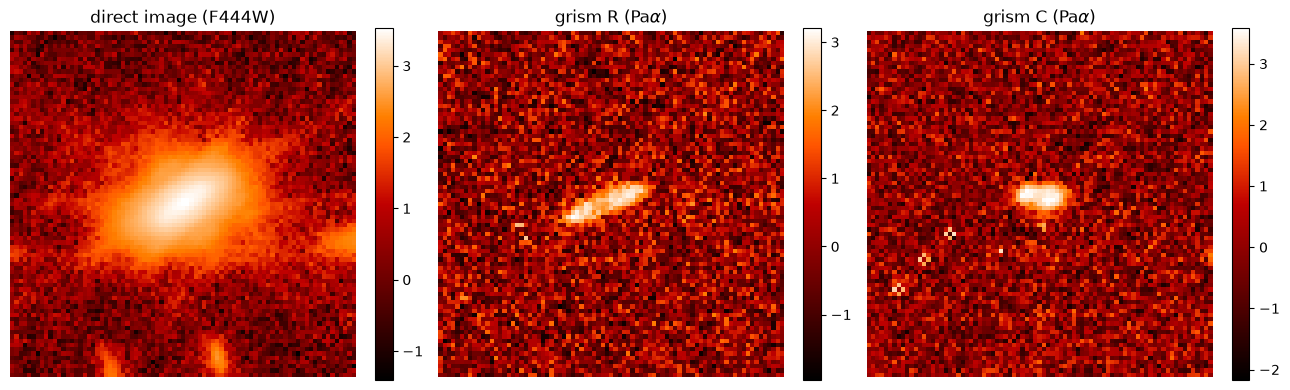

In [7]:
coadd_image = fits.getdata(f'ID{ID}/image.fits')
coadd_R     = fits.getdata(f'ID{ID}/R.fits')
coadd_C     = fits.getdata(f'ID{ID}/C.fits')
print(f'direct {coadd_image.shape}   R {coadd_R.shape}   C {coadd_C.shape}')

fig, axs = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, im, title in [(axs[0], coadd_image, 'direct image (F444W)'),
                      (axs[1], coadd_R,     'grism R (Pa$\\alpha$)'),
                      (axs[2], coadd_C,     'grism C (Pa$\\alpha$)')]:
    m = ax.imshow(asinhstretch(im), origin='lower')
    ax.set_title(title); ax.grid(False); ax.set_axis_off()
    fig.colorbar(m, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## Morphology from pysersic

The recipe from `master_run_Paalpha_clean_env.ipynb`: 40x40 cutout, webbPSF `DET_DIST`
cropped to 19x19, `sky_type='flat'`, `HybridRenderer`, 500 warmup / 1000 samples / 2 chains,
no mask.

`fitter.sample()` is not called: it dies in `PySersicResults._parse_injested_data` on
arviz >= 1.0 (`DataTree` has no `drop_vars`), *after* sampling. The NUTS call below is
what it runs internally.

11:26:53 - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/DINGO/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
11:26:53 - Found 'auto' as default backend, checking available backends
11:26:53 - Matplotlib is available, defining as default backend
11:26:53 - arviz_base 1.2.0 available, exposing its functions as part of the `arviz` namespace
11:26:53 - arviz_stats 1.2.0 available, exposing its functions as part of the `arviz` namespace
11:26:53 - arviz_plots 1.2.0 available, exposing its functions as part of the `arviz` namespace


ID 3700  RA 63.94578  Dec -24.18057  zspec 1.1231
cutout (40, 40) at 0.0300 arcsec/pix


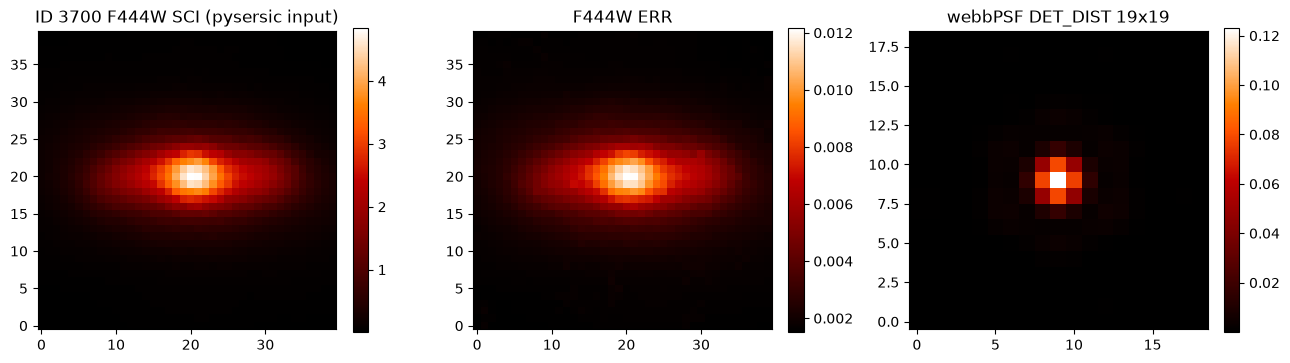

In [8]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.coordinates import SkyCoord

import jax
jax.config.update('jax_enable_x64', True)
from numpyro import infer
from pysersic.priors import SourceProperties
from pysersic import FitSingle
from pysersic.loss import gaussian_loss
from pysersic.rendering import HybridRenderer

# RA/Dec/z came from the catalogue, paths from the manifest cell
coord = SkyCoord(RA*u.deg, DEC*u.deg)
print(f'ID {ID}  RA {RA:.5f}  Dec {DEC:+.5f}  zspec {Z_CATALOG:.4f}')

with fits.open(MOSAIC_SCI) as h:
    mosaic_wcs = WCS(h[0].header)
    sci_cutout = Cutout2D(h[0].data, coord, CUTOUT_SIZE, wcs=mosaic_wcs)
with fits.open(MOSAIC_ERR) as h:
    err_cutout = Cutout2D(h[0].data, sci_cutout.input_position_original, CUTOUT_SIZE)
pixscale_mosaic = abs(mosaic_wcs.pixel_scale_matrix[0, 0])*3600
print(f'cutout {sci_cutout.data.shape} at {pixscale_mosaic:.4f} arcsec/pix')

with fits.open(PSF_FILE) as ph:
    try:
        psf_morph = ph['DET_DIST'].data.copy()
    except KeyError:
        psf_morph = ph[0].data.copy()
if psf_morph.shape[0] > 19:
    c = psf_morph.shape[0]//2
    psf_morph = psf_morph[c-9:c+10, c-9:c+10]
psf_morph = np.nan_to_num(psf_morph, nan=0.0, posinf=0.0, neginf=0.0)
psf_morph = psf_morph/psf_morph.sum()

fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
for a, im, t in [(ax[0], sci_cutout.data, f'ID {ID} {PYSERSIC_FILTER} SCI (pysersic input)'),
                 (ax[1], err_cutout.data, f'{PYSERSIC_FILTER} ERR'),
                 (ax[2], psf_morph,       'webbPSF DET_DIST 19x19')]:
    m = a.imshow(im, origin='lower', cmap='gist_heat'); a.set_title(t); a.grid(False)
    fig.colorbar(m, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

Prior for a sersic source:
--------------------------
flux ---  Normal w/ mu = 762.62, sigma = 55.23
xc ---  Normal w/ mu = 19.50, sigma = 1.00
yc ---  Normal w/ mu = 19.50, sigma = 1.00
r_eff ---  Truncated Normal w/ mu = 7.41, sigma = 5.45, between: 0.50 -> inf
ellip ---  Uniform between: 0.00 -> 0.90
theta ---  Uniform between: 0.00 -> 6.28
n ---  Uniform between: 0.65 -> 8.00
sky type - flat
sky_back --- Normal with mu = 4.748e-02 and sd = 2.422e-03



sample: 100%|██████████| 1500/1500 [00:47<00:00, 31.54it/s, 1023 steps of size 9.88e-03. acc. prob=0.92]



                  mean       std    median      5.0%     95.0%     n_eff     r_hat
  ellip_base      0.63      0.00      0.63      0.63      0.63     24.66      1.06
   flux_base     -2.92      0.05     -2.93     -2.93     -2.92     15.25      1.08
      n_base      0.00      0.00      0.00      0.00      0.00     14.86      1.08
  r_eff_base      0.11      0.00      0.11      0.11      0.11     14.70      1.08
    sky_back      0.05      0.00      0.05      0.05      0.05     56.58      1.03
  theta_base      0.50      0.25      0.50      0.25      0.75      1.00  11271.61
     xc_base      1.11      0.01      1.11      1.11      1.11     72.08      1.02
     yc_base      0.52      0.00      0.52      0.52      0.52   1540.24      1.00

Number of divergences: 0

retrieve_param_quantiles([0.16, 0.50, 0.84]):
            0.16       0.50       0.84
ellip   0.566900   0.567020   0.567132
n       0.650005   0.650015   0.650040
r_eff   8.012789   8.014035   8.015540
theta   1.560617   3.13

11:28:10 - Too few points to create valid contours
11:28:10 - Too few points to create valid contours
11:28:10 - Too few points to create valid contours
11:28:10 - Too few points to create valid contours
11:28:10 - Too few points to create valid contours
11:28:10 - Too few points to create valid contours


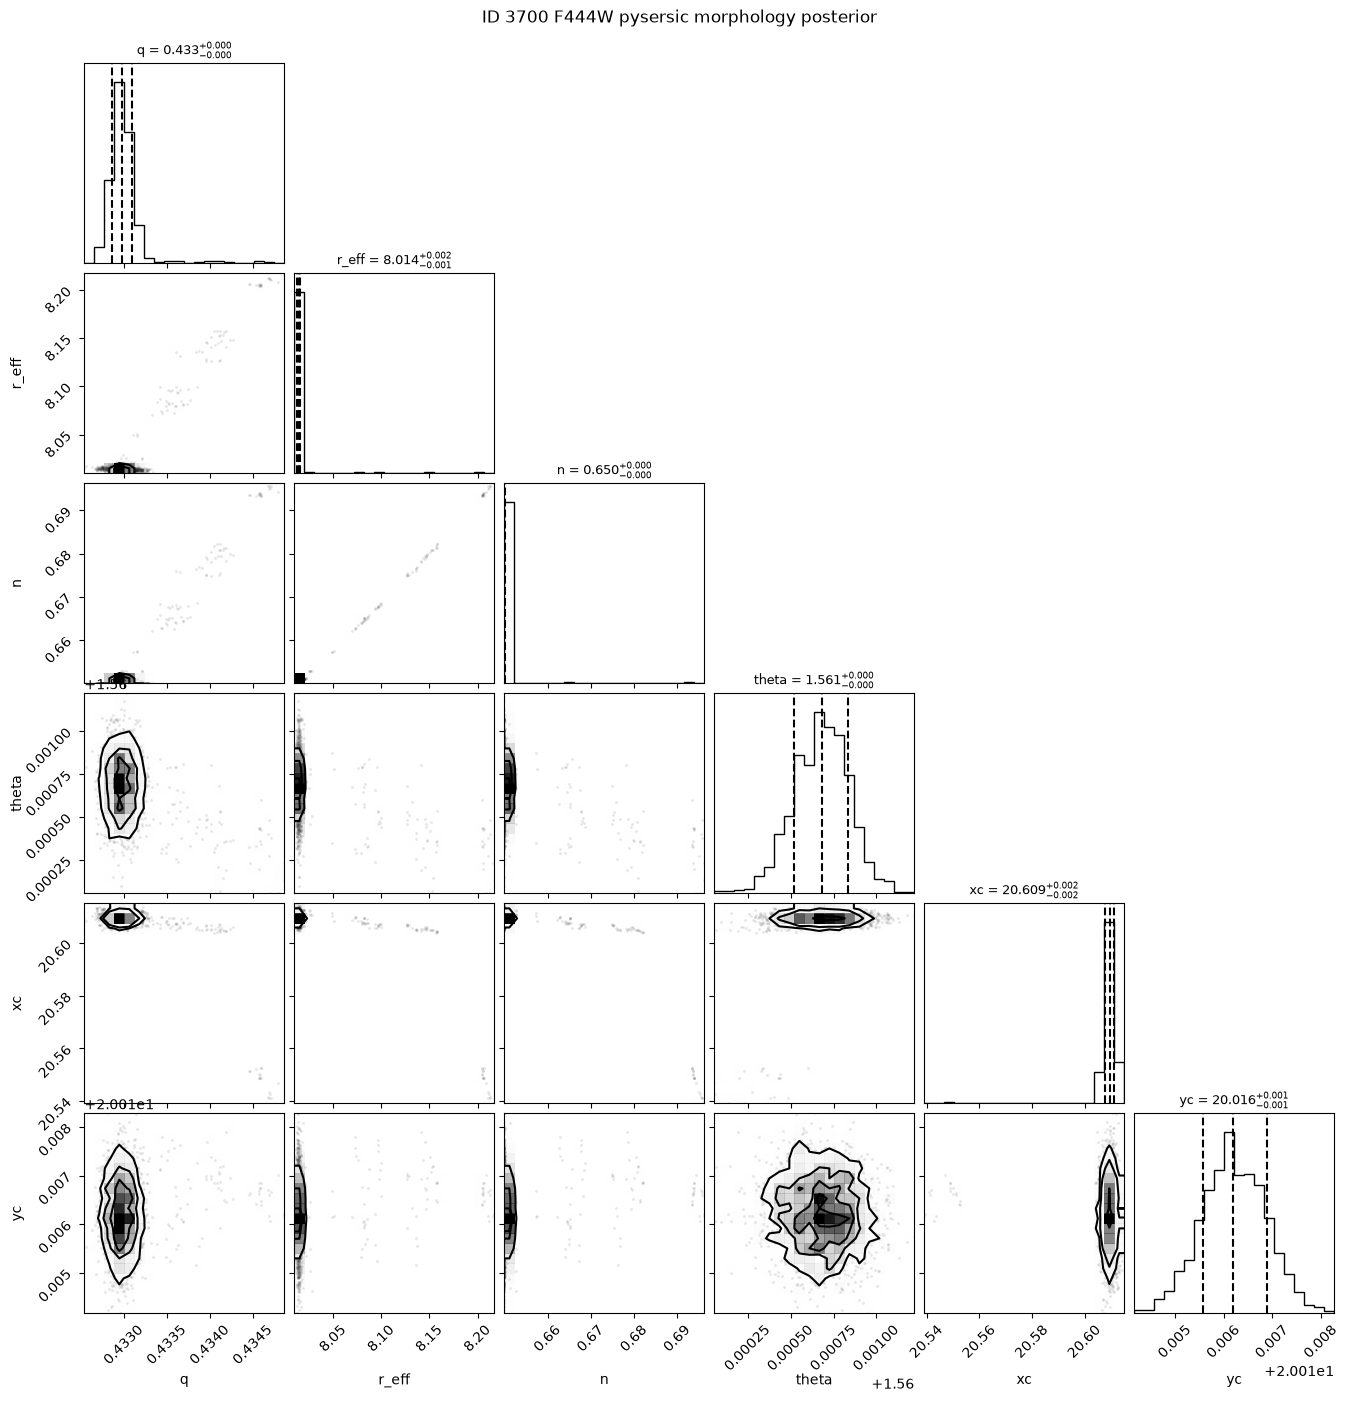

saved -> /Users/aakavan/Astro_Research/Galaxy_Kinematics/DINGO_development/results/ID3700/ID3700_sersic_F444W_pysersic_notebook.npz


In [9]:
if RUN_PYSERSIC:
    sp = SourceProperties(sci_cutout.data)
    sp.set_position_guess(position_guess=(CUTOUT_SIZE/2 - 0.5, CUTOUT_SIZE/2 - 0.5))
    prior = sp.generate_prior('sersic', sky_type='flat')
    print(prior)

    fitter = FitSingle(data=sci_cutout.data, rms=err_cutout.data, psf=psf_morph,
                       prior=prior, renderer=HybridRenderer, loss_func=gaussian_loss)

    # what fitter.sample() runs internally, minus the arviz post-processing it dies on
    # chain_method stays 'sequential': numpyro's 'parallel' path pmaps over devices and
    # raises "Vector and operator structures do not match" with this jax/numpyro pair.
    # N_CORES still applies -- it sets the intra-op thread count each chain uses.
    sampler = infer.MCMC(infer.NUTS(fitter.build_model(return_model=False),
                                    init_strategy=infer.init_to_sample),
                         num_chains=2, num_warmup=500, num_samples=1000,
                         chain_method='sequential')
    sampler.run(jax.random.PRNGKey(42))
    sampler.print_summary(exclude_deterministic=True)
    pysersic_post = sampler.get_samples()

    cols = ['ellip', 'n', 'r_eff', 'theta', 'xc', 'yc']
    q_table = pd.DataFrame(
        {p: [np.percentile(np.asarray(pysersic_post[c]).ravel(), 100*p) for c in cols]
         for p in (0.16, 0.50, 0.84)}, index=cols)
    print('\nretrieve_param_quantiles([0.16, 0.50, 0.84]):')
    print(q_table)

    q_samples = 1.0 - np.asarray(pysersic_post['ellip']).ravel()
    inc_samples = np.arccos(np.clip(q_samples, 0.0, 1.0))
    ql, qm, qh = np.percentile(q_samples, [16, 50, 84])
    il, im_, ih = np.percentile(inc_samples, [16, 50, 84])
    print(f'\naxis ratio   q = {qm:.4f} -{qm-ql:.4f} +{qh-qm:.4f}')
    print(f'inclination  i = {im_:.4f} -{im_-il:.4f} +{ih-im_:.4f} rad '
          f'({np.rad2deg(im_):.2f} deg)      [q = cos i, the geometry the velocity model assumes]')
    print(f'r_eff = {q_table.loc["r_eff", 0.50]:.2f} pix '
          f'= {q_table.loc["r_eff", 0.50]*pixscale_mosaic:.4f} arcsec,  '
          f'n = {q_table.loc["n", 0.50]:.3f}')

    print('\n--- inclination estimates on the table ---')
    print(f'{"method":<46}{"inc [rad]":>11}{"inc [deg]":>11}')
    for label, val in [('pysersic, no mask, 40x40 (this cell)', im_),
                       ('pysersic, core-masked (measure_inclination.py)', 0.5801),
                       ('emcee Sersic, core-masked', 0.5850),
                       ('elliptical annuli, F444W (mean)', 0.6338),
                       ('adopted prior for the MCMC run', 0.6412),
                       ('KINEMATIC fit, no inclination prior', 0.4380)]:
        print(f'{label:<46}{val:>11.4f}{np.rad2deg(val):>11.2f}')

    # corner plot of the morphology posterior
    import corner
    corner_cols = ['q', 'r_eff', 'n', 'theta', 'xc', 'yc']
    corner_data = np.column_stack([
        q_samples,
        np.asarray(pysersic_post['r_eff']).ravel(),
        np.asarray(pysersic_post['n']).ravel(),
        np.remainder(np.asarray(pysersic_post['theta']).ravel() + np.pi, np.pi),
        np.asarray(pysersic_post['xc']).ravel(),
        np.asarray(pysersic_post['yc']).ravel()])
    fig = corner.corner(corner_data, labels=corner_cols, show_titles=True,
                        title_fmt='.3f', quantiles=[0.16, 0.5, 0.84],
                        title_kwargs={'fontsize': 9}, label_kwargs={'fontsize': 10})
    fig.suptitle(f'ID {ID} {PYSERSIC_FILTER} pysersic morphology posterior', y=1.01)
    fig.savefig(out(f'sersic_{PYSERSIC_FILTER}_pysersic_corner.png'),
                dpi=120, bbox_inches='tight')
    plt.show()
    np.savez_compressed(out(f'sersic_{PYSERSIC_FILTER}_pysersic_notebook.npz'),
                        **{c: np.asarray(pysersic_post[c]).ravel() for c in cols},
                        q=q_samples, inc=inc_samples)
    print('saved ->', out(f'sersic_{PYSERSIC_FILTER}_pysersic_notebook.npz'))

    PYSERSIC_INC, PYSERSIC_INC_SIG = float(im_), float(max(ih - im_, im_ - il))
else:
    PYSERSIC_INC = PYSERSIC_INC_SIG = None
    print('RUN_PYSERSIC = False -- skipping the morphology fit')

## Fit the rotation curve (Adam / LBFGS, the MAP)

In [10]:
kinematics_fitter = fitting.KinematicsFitter(config_path=CONFIG)
all_losses, all_lrs = kinematics_fitter.fit_all()

image_R, image_C, vz_R, vz_C = kinematics_fitter.get_fitting_results()
velocity_params, dispersion_params_R, dispersion_params_C = kinematics_fitter.get_params()
true_grism_R, true_grism_C = kinematics_fitter.get_true_images()

def print_params(title, params):
    print(f'\n[{title}]')
    for name, param in params.items():
        if isinstance(param, (numbers.Number, np.number)):
            print(f'{name:10s} = {param:.4f}')
        else:
            print(f'{name:10s} = {param}')

print_params('Velocity', velocity_params)
print_params('Dispersion R', dispersion_params_R)
print_params('Dispersion C', dispersion_params_C)

11:28:11 - WARNING - dingo.fitting - [KinematicsFitter] summary.r_fit is deprecated under (x,y) origin=(0,0). Prefer explicit cutouts/centers in the config.
11:28:11 - [KinematicsFitter] summary.r_fit is deprecated under (x,y) origin=(0,0). Prefer explicit cutouts/centers in the config.
11:28:11 - INFO - dingo.fitting - [KinematicsFitter] using coordinate unit = pix
11:28:11 - [KinematicsFitter] using coordinate unit = pix
11:28:11 - WARNING - dingo.fitting - [KinematicsFitter] image.R.cutout is missing; derived (15, 8, 81, 81) from summary.r_fit=40. Prefer an explicit cutout.
11:28:11 - [KinematicsFitter] image.R.cutout is missing; derived (15, 8, 81, 81) from summary.r_fit=40. Prefer an explicit cutout.
11:28:11 - WARNING - dingo.fitting - [KinematicsFitter] image.C.cutout is missing; derived (29, -54, 81, 81) from summary.r_fit=40. Prefer an explicit cutout.
11:28:11 - [KinematicsFitter] image.C.cutout is missing; derived (29, -54, 81, 81) from summary.r_fit=40. Prefer an explicit c


[Velocity]
V_rot      = -372.21453857421875
R_v        = 2.2698965072631836
x0_v       = 40.9794921875
y0_v       = 39.54903030395508
theta_v    = 0.43840306997299194
inc_v      = 0.736111581325531

[Dispersion R]
dx         = 2.17734694480896
dy         = -0.3000309467315674
forward_model = <function get_grism_model_torch.<locals>.grism_inverse_model at 0x3b2450c20>

[Dispersion C]
dx         = 0.3163875937461853
dy         = -0.48806262016296387
forward_model = <function get_grism_model_torch.<locals>.grism_inverse_model at 0x3b2451940>


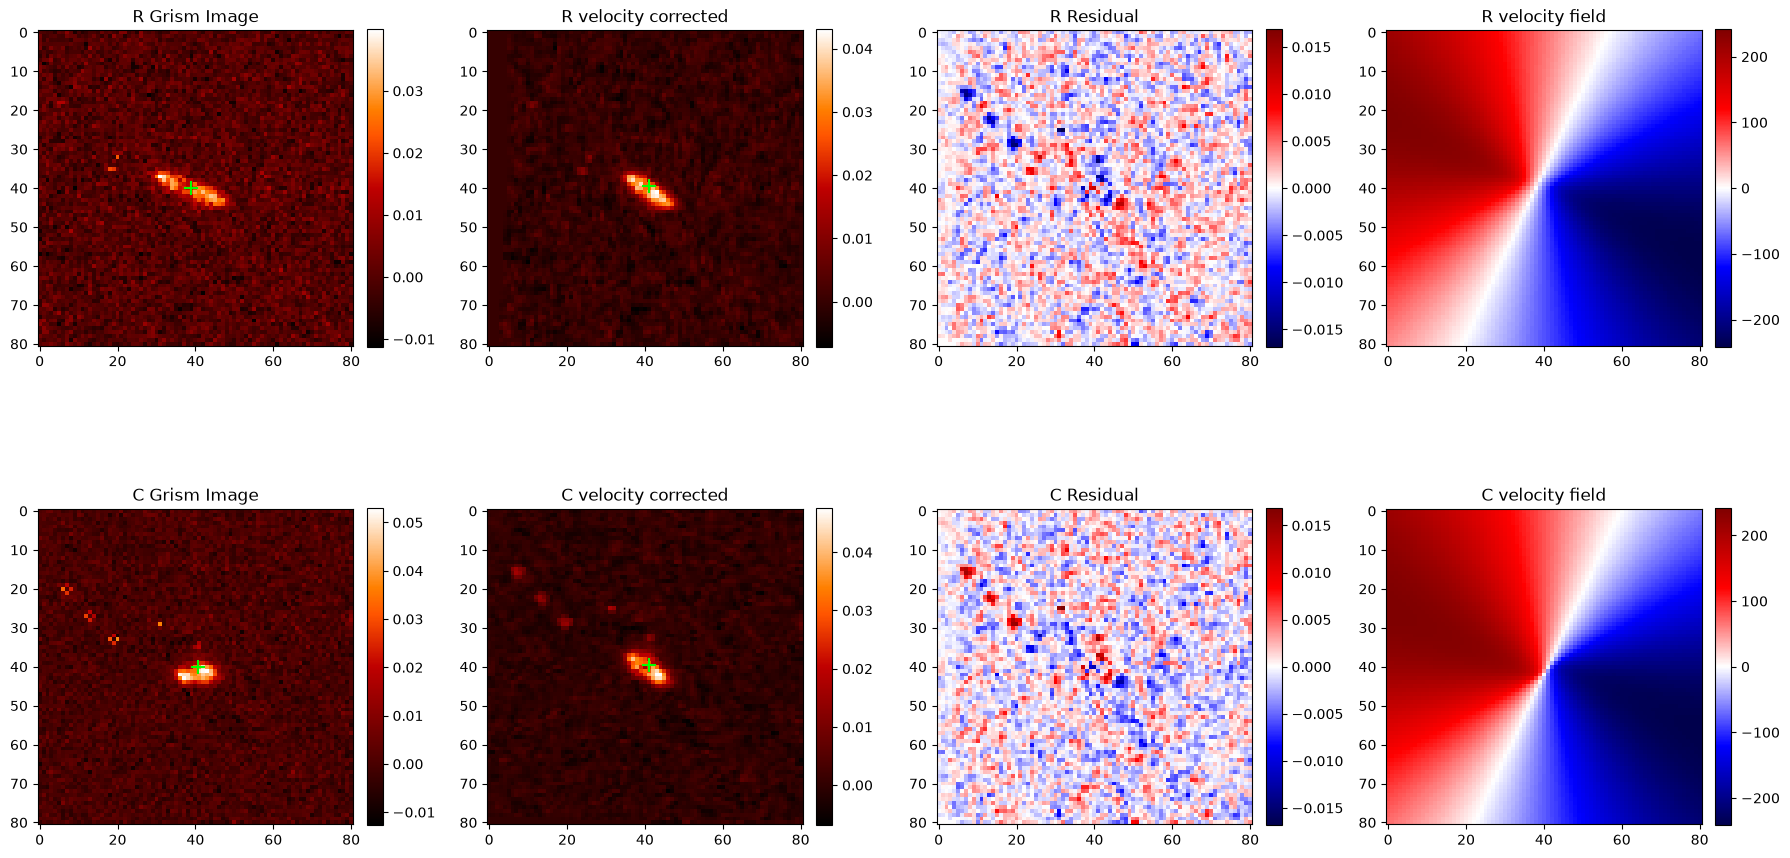

In [11]:
fig, axs = plt.subplots(2, 4, figsize=(18, 10))
plot.plot_kinematics_fitting_result(true_grism_R, image_R, vz_R, image_C, 'R',
                                    axs[0], velocity_params, dispersion_params_R)
plot.plot_kinematics_fitting_result(true_grism_C, image_C, vz_C, image_R, 'C',
                                    axs[1], velocity_params, dispersion_params_C)
plt.tight_layout(); plt.show()

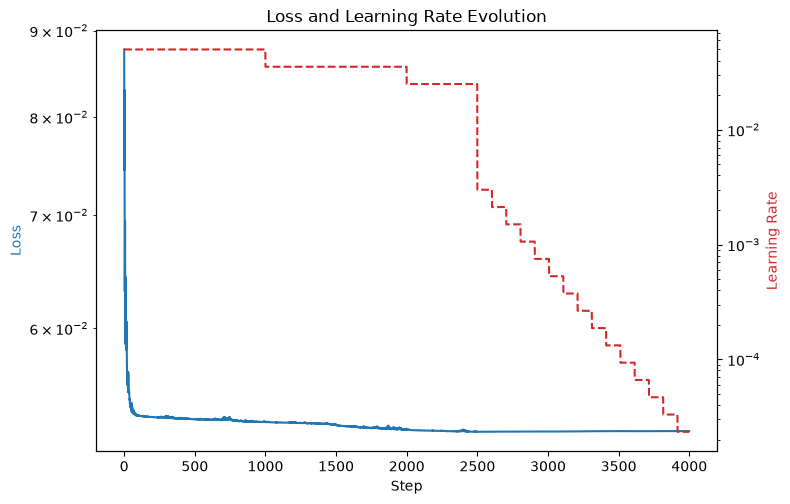

In [12]:
plot.plot_loss_and_lr(sum(all_losses, []), sum(all_lrs, []))

In [13]:
# Feed the measured morphology into the kinematics prior. q = cos(i) exactly in
# DINGO's convention: sersic_model_torch and arctangent_disk_velocity_model use the
# same deprojection, R = sqrt(x'^2 + (y'/q)^2).
#
# The formal pysersic error (~0.01 rad) is far too tight to use as a prior width --
# a single Sersic cannot describe this galaxy at ~1000 sigma per pixel, and the
# spread BETWEEN methods (Sersic vs elliptical annuli, F444W vs F200W) is what
# actually limits the measurement. Floor the width at the measured method scatter.
METHOD_SCATTER = 0.0436          # rad; see MCMC_STATUS.md for the eight estimates

if USE_PYSERSIC_PRIOR and PYSERSIC_INC is not None:
    sigma = max(PYSERSIC_INC_SIG, METHOD_SCATTER)
    kinematics_fitter.config.setdefault('mcmc', {}).setdefault('priors', {})
    old = kinematics_fitter.config['mcmc']['priors'].get('velocity.inc_v')
    kinematics_fitter.config['mcmc']['priors']['velocity.inc_v'] = {
        'type': 'gaussian', 'mu': PYSERSIC_INC, 'sigma': sigma,
        'min': 0.0873, 'max': 1.4835}
    print(f'inc_v prior <- pysersic: mu = {PYSERSIC_INC:.4f}, sigma = {sigma:.4f} rad '
          f'({np.rad2deg(PYSERSIC_INC):.2f} +- {np.rad2deg(sigma):.2f} deg)')
    print(f'  formal pysersic width {PYSERSIC_INC_SIG:.4f} -> floored at {METHOD_SCATTER}')
    print(f'  config value it replaces: {old}')
else:
    print('using the inc_v prior as written in the config:')
    print(' ', (kinematics_fitter.config.get('mcmc', {}).get('priors', {})
                .get('velocity.inc_v')))

inc_v prior <- pysersic: mu = 1.1230, sigma = 0.0436 rad (64.34 +- 2.50 deg)
  formal pysersic width 0.0001 -> floored at 0.0436
  config value it replaces: {'type': 'sin_i', 'min': 0.0873, 'max': 1.4835}


## MCMC posterior

`fit_MCMC` samples the 10 free kinematic scalars plus a noise scale `ln f`, with a
Gaussian likelihood built on the background sigma of each grism image.

In [14]:
if RUN_MCMC or not os.path.exists(CHAIN):
    kinematics_fitter.setup_noise_model()
    kinematics_fitter.fit_MCMC()
    kinematics_fitter.save_mcmc(CHAIN)
    saved = np.load(CHAIN, allow_pickle=True)
else:
    saved = np.load(CHAIN, allow_pickle=True)
    print(f'loaded {CHAIN}')

chain  = saved['chain']                       # (nsteps, nwalkers, ndim)
names  = [str(s) for s in saved['param_names']]
nburn  = int(saved['nburn'])
flat   = chain[nburn:].reshape(-1, chain.shape[-1])
print(f'chain {chain.shape}, burn-in {nburn}, {flat.shape[0]} samples')
print(f'mean acceptance = {np.mean(saved["acceptance_fraction"]):.3f}')

post = {}
print(f'\n{"parameter":<20}{"median":>12}{"-1sigma":>10}{"+1sigma":>10}')
for j, n in enumerate(names):
    lo, med, hi = np.percentile(flat[:, j], [16, 50, 84])
    post[n] = med
    print(f'{n:<20}{med:>12.4f}{med-lo:>10.4f}{hi-med:>10.4f}')

11:28:46 - INFO - dingo.fitting - [MCMC] noise model frozen: sigma_R=0.0032329 sigma_C=0.0029453 var_base=1.9126e-05 N_pix=6142/6561 (mask drops 0.7% of the flux)
11:28:46 - [MCMC] noise model frozen: sigma_R=0.0032329 sigma_C=0.0029453 var_base=1.9126e-05 N_pix=6142/6561 (mask drops 0.7% of the flux)
11:28:46 - INFO - dingo.fitting - [MCMC] sampling the free parameters of fitting stage 1
11:28:46 - [MCMC] sampling the free parameters of fitting stage 1
11:28:46 - INFO - dingo.fitting - [MCMC] skipping array parameter result.emline_model (6561 elements)
11:28:46 - [MCMC] skipping array parameter result.emline_model (6561 elements)
11:28:46 - INFO - dingo.fitting - [MCMC] V_rot is negative (-372.21); reflecting onto the positive branch with theta_v -> theta_v + pi (identical velocity field)
11:28:46 - [MCMC] V_rot is negative (-372.21); reflecting onto the positive branch with theta_v -> theta_v + pi (identical velocity field)
11:28:47 - INFO - dingo.fitting - [MCMC] ndim=11 nwalkers=32

chain (10000, 32, 11), burn-in 2000, 256000 samples
mean acceptance = 0.198

parameter                 median   -1sigma   +1sigma
velocity.V_rot          389.7435    9.5911   10.3964
velocity.R_v              2.3398    0.0571    0.0523
velocity.x0_v            40.7853    0.0625    0.0627
velocity.y0_v            39.6955    0.1155    0.1085
velocity.theta_v          3.5841    0.0081    0.0083
velocity.inc_v            0.7024    0.0233    0.0228
image.R.dx                2.1714    0.0172    0.0172
image.R.dy               -0.2984    0.0091    0.0094
image.C.dx                0.3174    0.0101    0.0100
image.C.dy               -0.5010    0.0174    0.0178
noise.ln_f               -0.4160    0.0088    0.0090


### Convergence

`tau` is the integrated autocorrelation time -- how many steps the chain takes to forget
where it was. `n_steps/tau` is the number of effectively independent samples per walker,
and it is the number that decides whether a posterior width can be believed:
**want > 50**.

No R-hat: emcee is an *ensemble* sampler, so walkers propose from one another and are not
independent chains. Gelman-Rubin is optimistic by construction here and would give false
reassurance.

In [15]:
if 'kinematics_fitter' in dir() and getattr(kinematics_fitter, 'mcmc_sampler', None):
    d = kinematics_fitter.get_mcmc_diagnostics()
    print(f"steps {d['n_steps']} after {d['n_burn']} burn   "
          f"acceptance {d['acceptance_fraction'][0]:.3f} "
          f"(min {d['acceptance_fraction'][1]:.2f}, max {d['acceptance_fraction'][2]:.2f})")
    print(f"fraction of -inf evaluations: {d['frac_neg_inf']:.4f}\n")
    hdr = f'{"parameter":<20}{"tau":>9}{"n/tau":>9}{"split shift":>13}  flag'
    print(hdr); print('-'*len(hdr))
    for n in kinematics_fitter.mcmc_param_names:
        ntau = d['n_steps_over_tau'][n]
        flags = []
        if not (ntau > 50): flags.append('n/tau<50')
        if d['split_half_shift'][n] > 0.2: flags.append('drifting')
        print(f'{n:<20}{d["tau"][n]:>9.1f}{ntau:>9.1f}'
              f'{d["split_half_shift"][n]:>13.3f}  {", ".join(flags)}')
    worst = min(d['n_steps_over_tau'].values())
    print(f'\nworst n_steps/tau = {worst:.1f} '
          f'({"OK" if worst > 50 else "SHORT -- run more steps before quoting widths"})')
else:
    print('no chain in memory -- set RUN_MCMC = True and run the sampling cell')

steps 8000 after 2000 burn   acceptance 0.198 (min 0.19, max 0.21)
fraction of -inf evaluations: 0.0000

parameter                 tau    n/tau  split shift  flag
---------------------------------------------------------
velocity.V_rot           56.8    140.8        0.063  
velocity.R_v             52.8    151.4        0.024  
velocity.x0_v            51.1    156.5        0.059  
velocity.y0_v            52.1    153.6        0.067  
velocity.theta_v         54.8    146.0        0.070  
velocity.inc_v           57.2    139.9        0.048  
image.R.dx               47.6    167.9        0.052  
image.R.dy               54.3    147.2        0.079  
image.C.dx               48.7    164.3        0.012  
image.C.dy               51.6    155.0        0.014  
noise.ln_f               49.3    162.4        0.018  

worst n_steps/tau = 139.9 (OK)


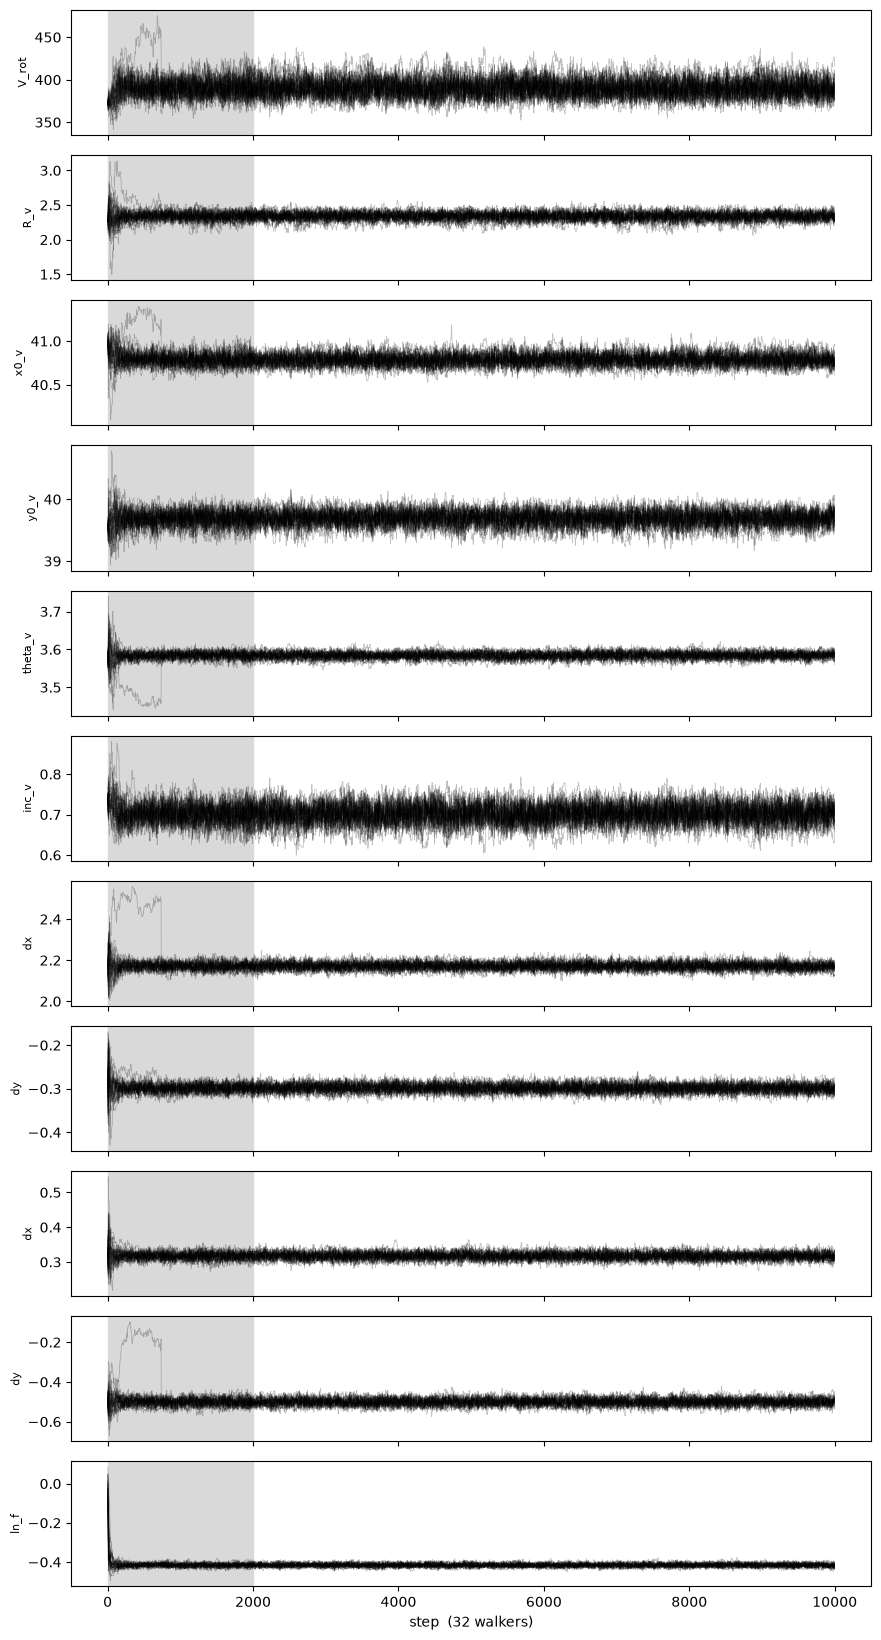

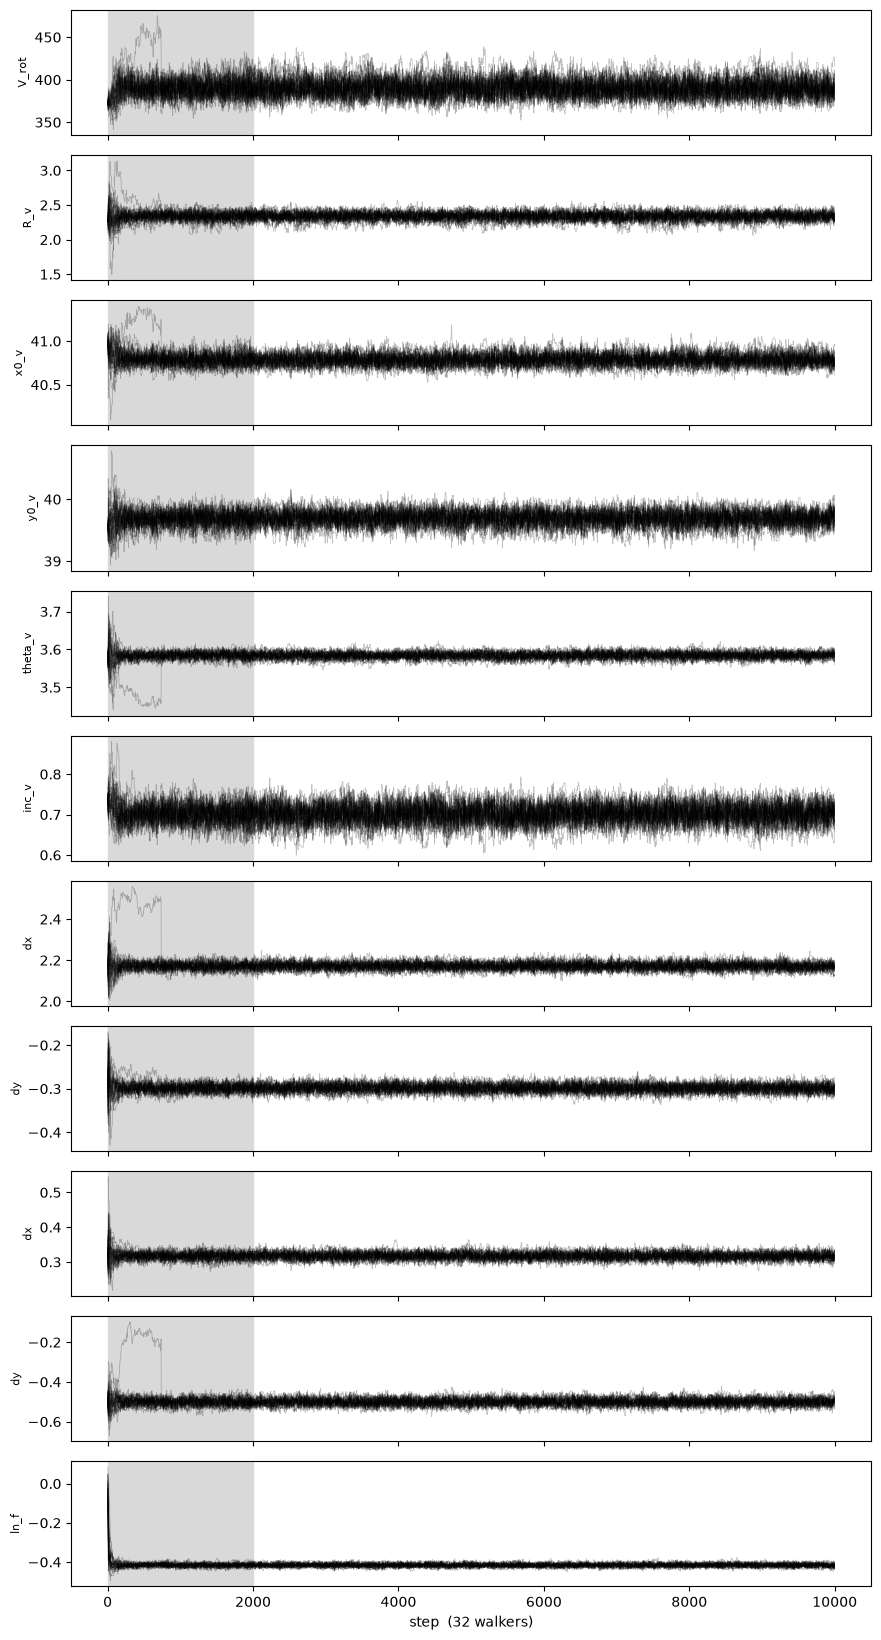

In [16]:
plot.plot_mcmc_chains(chain, names, nburn=nburn)

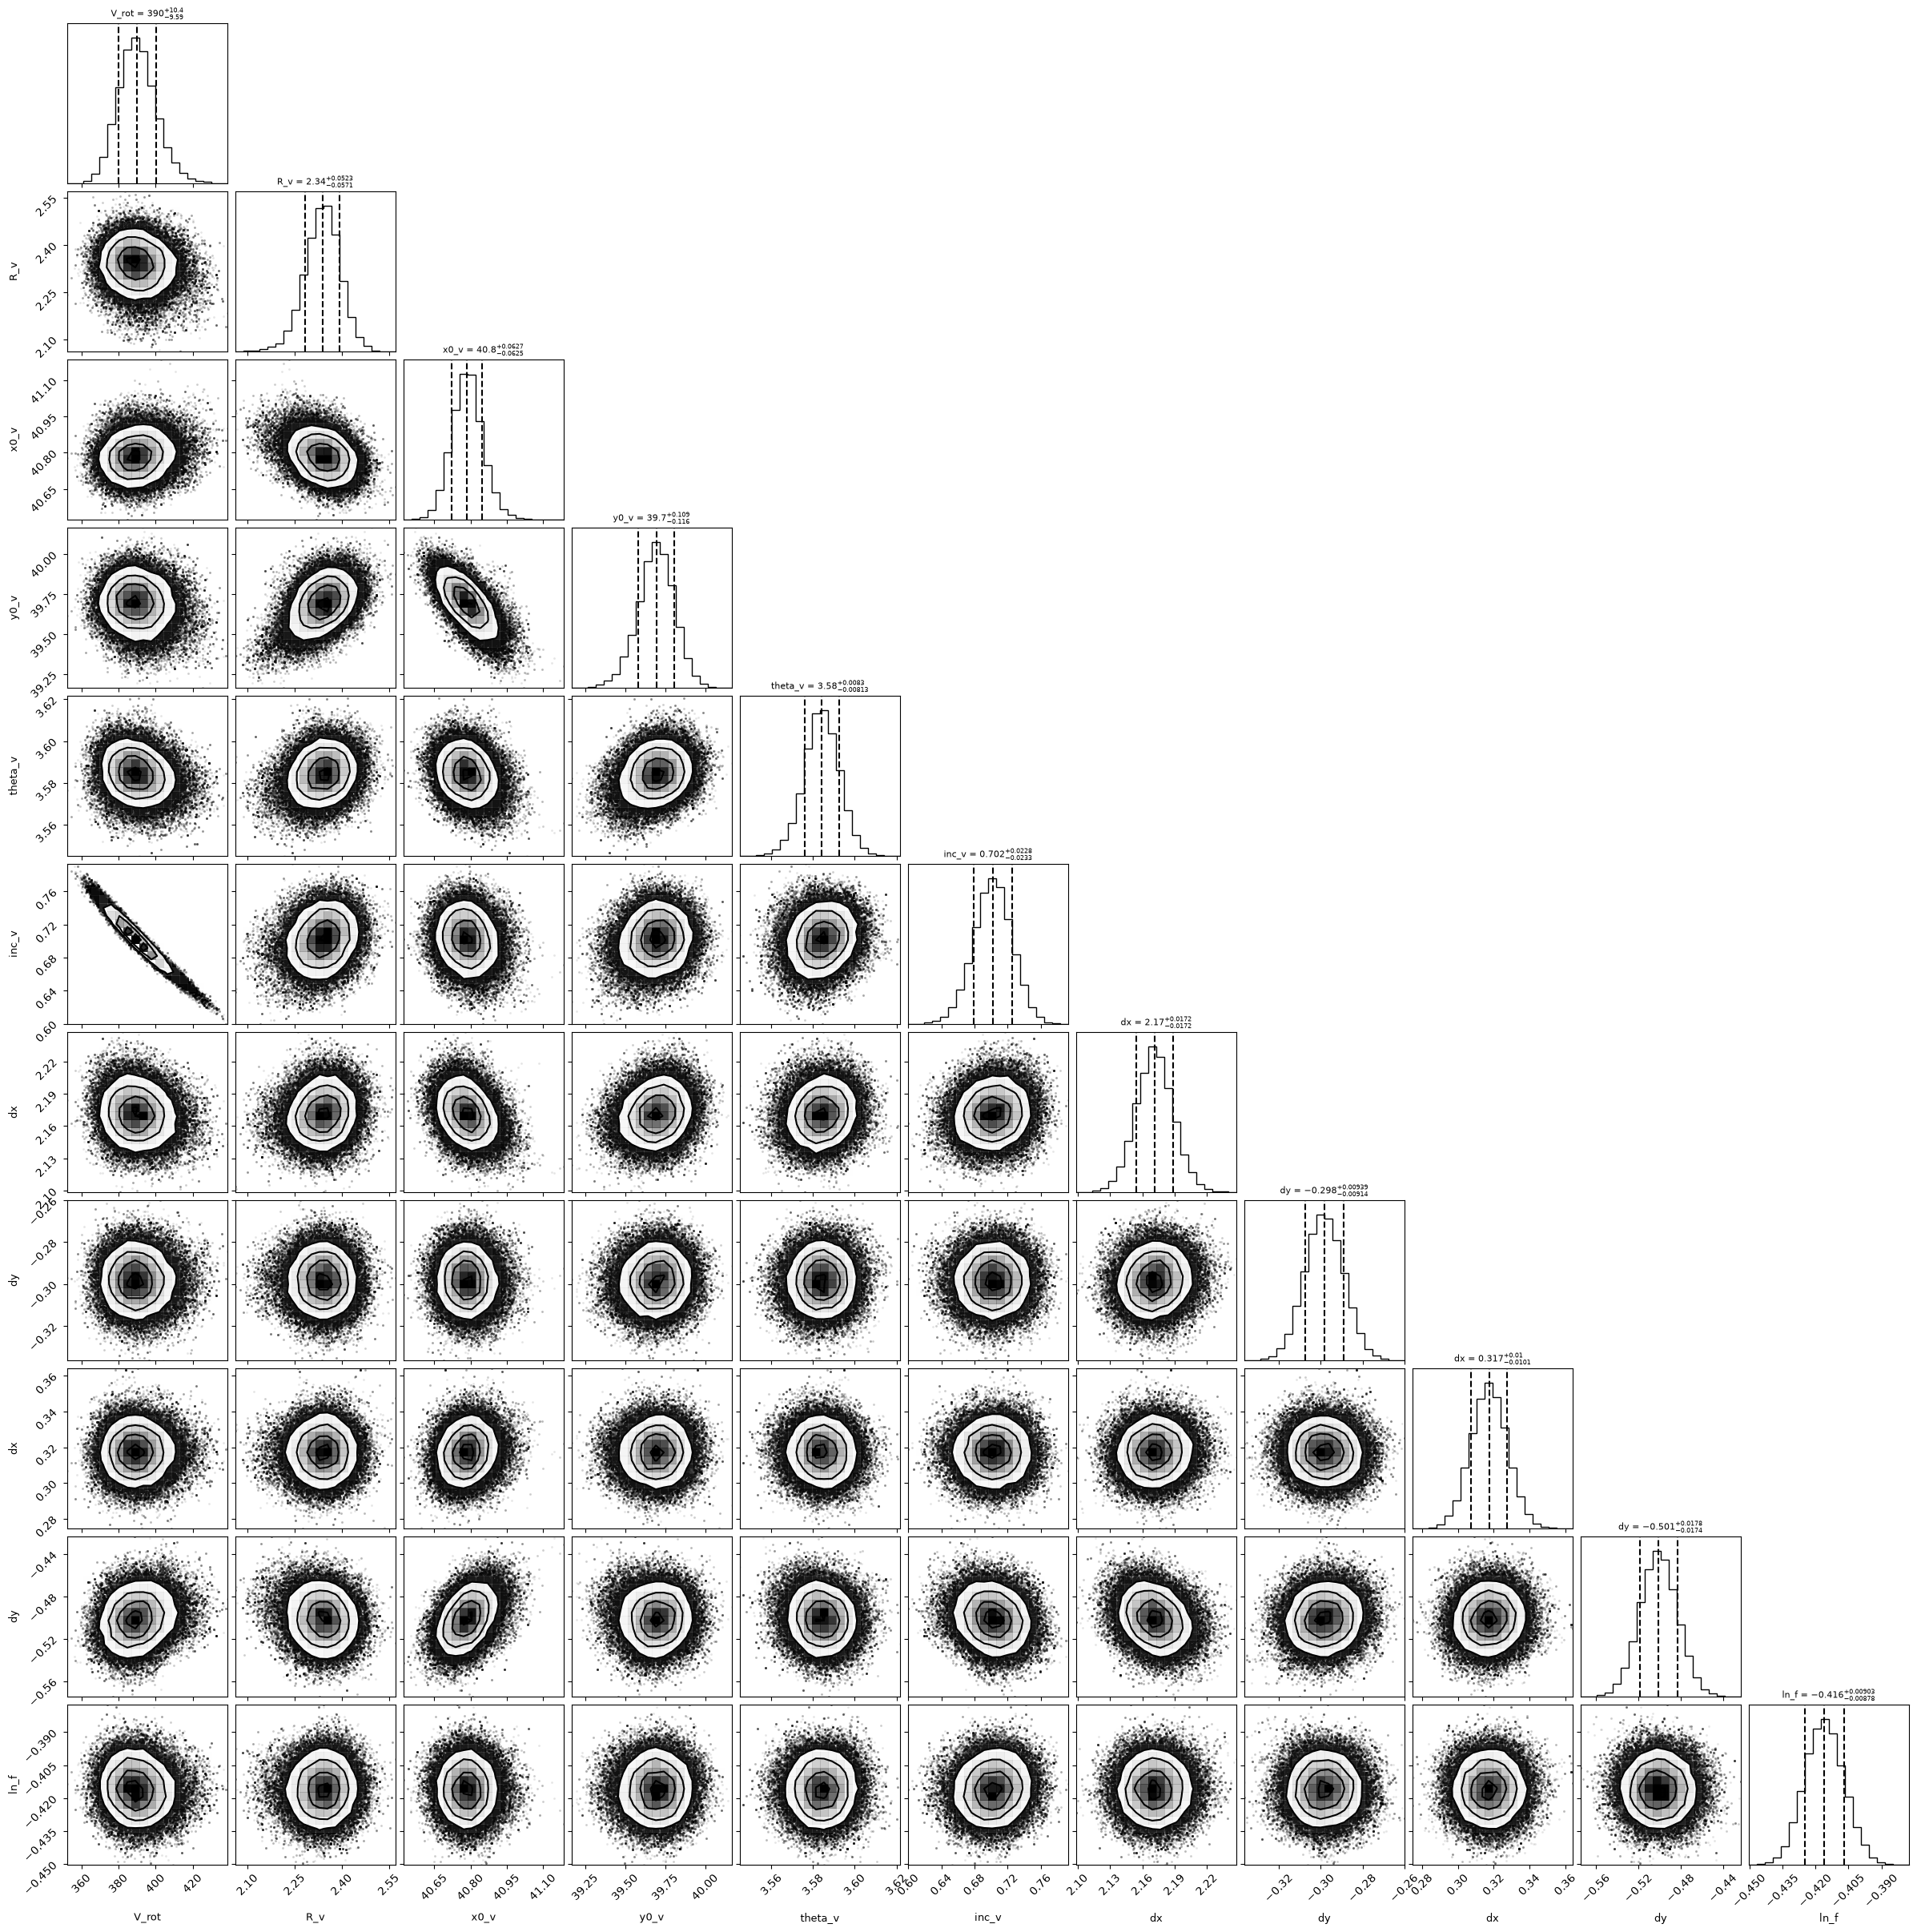

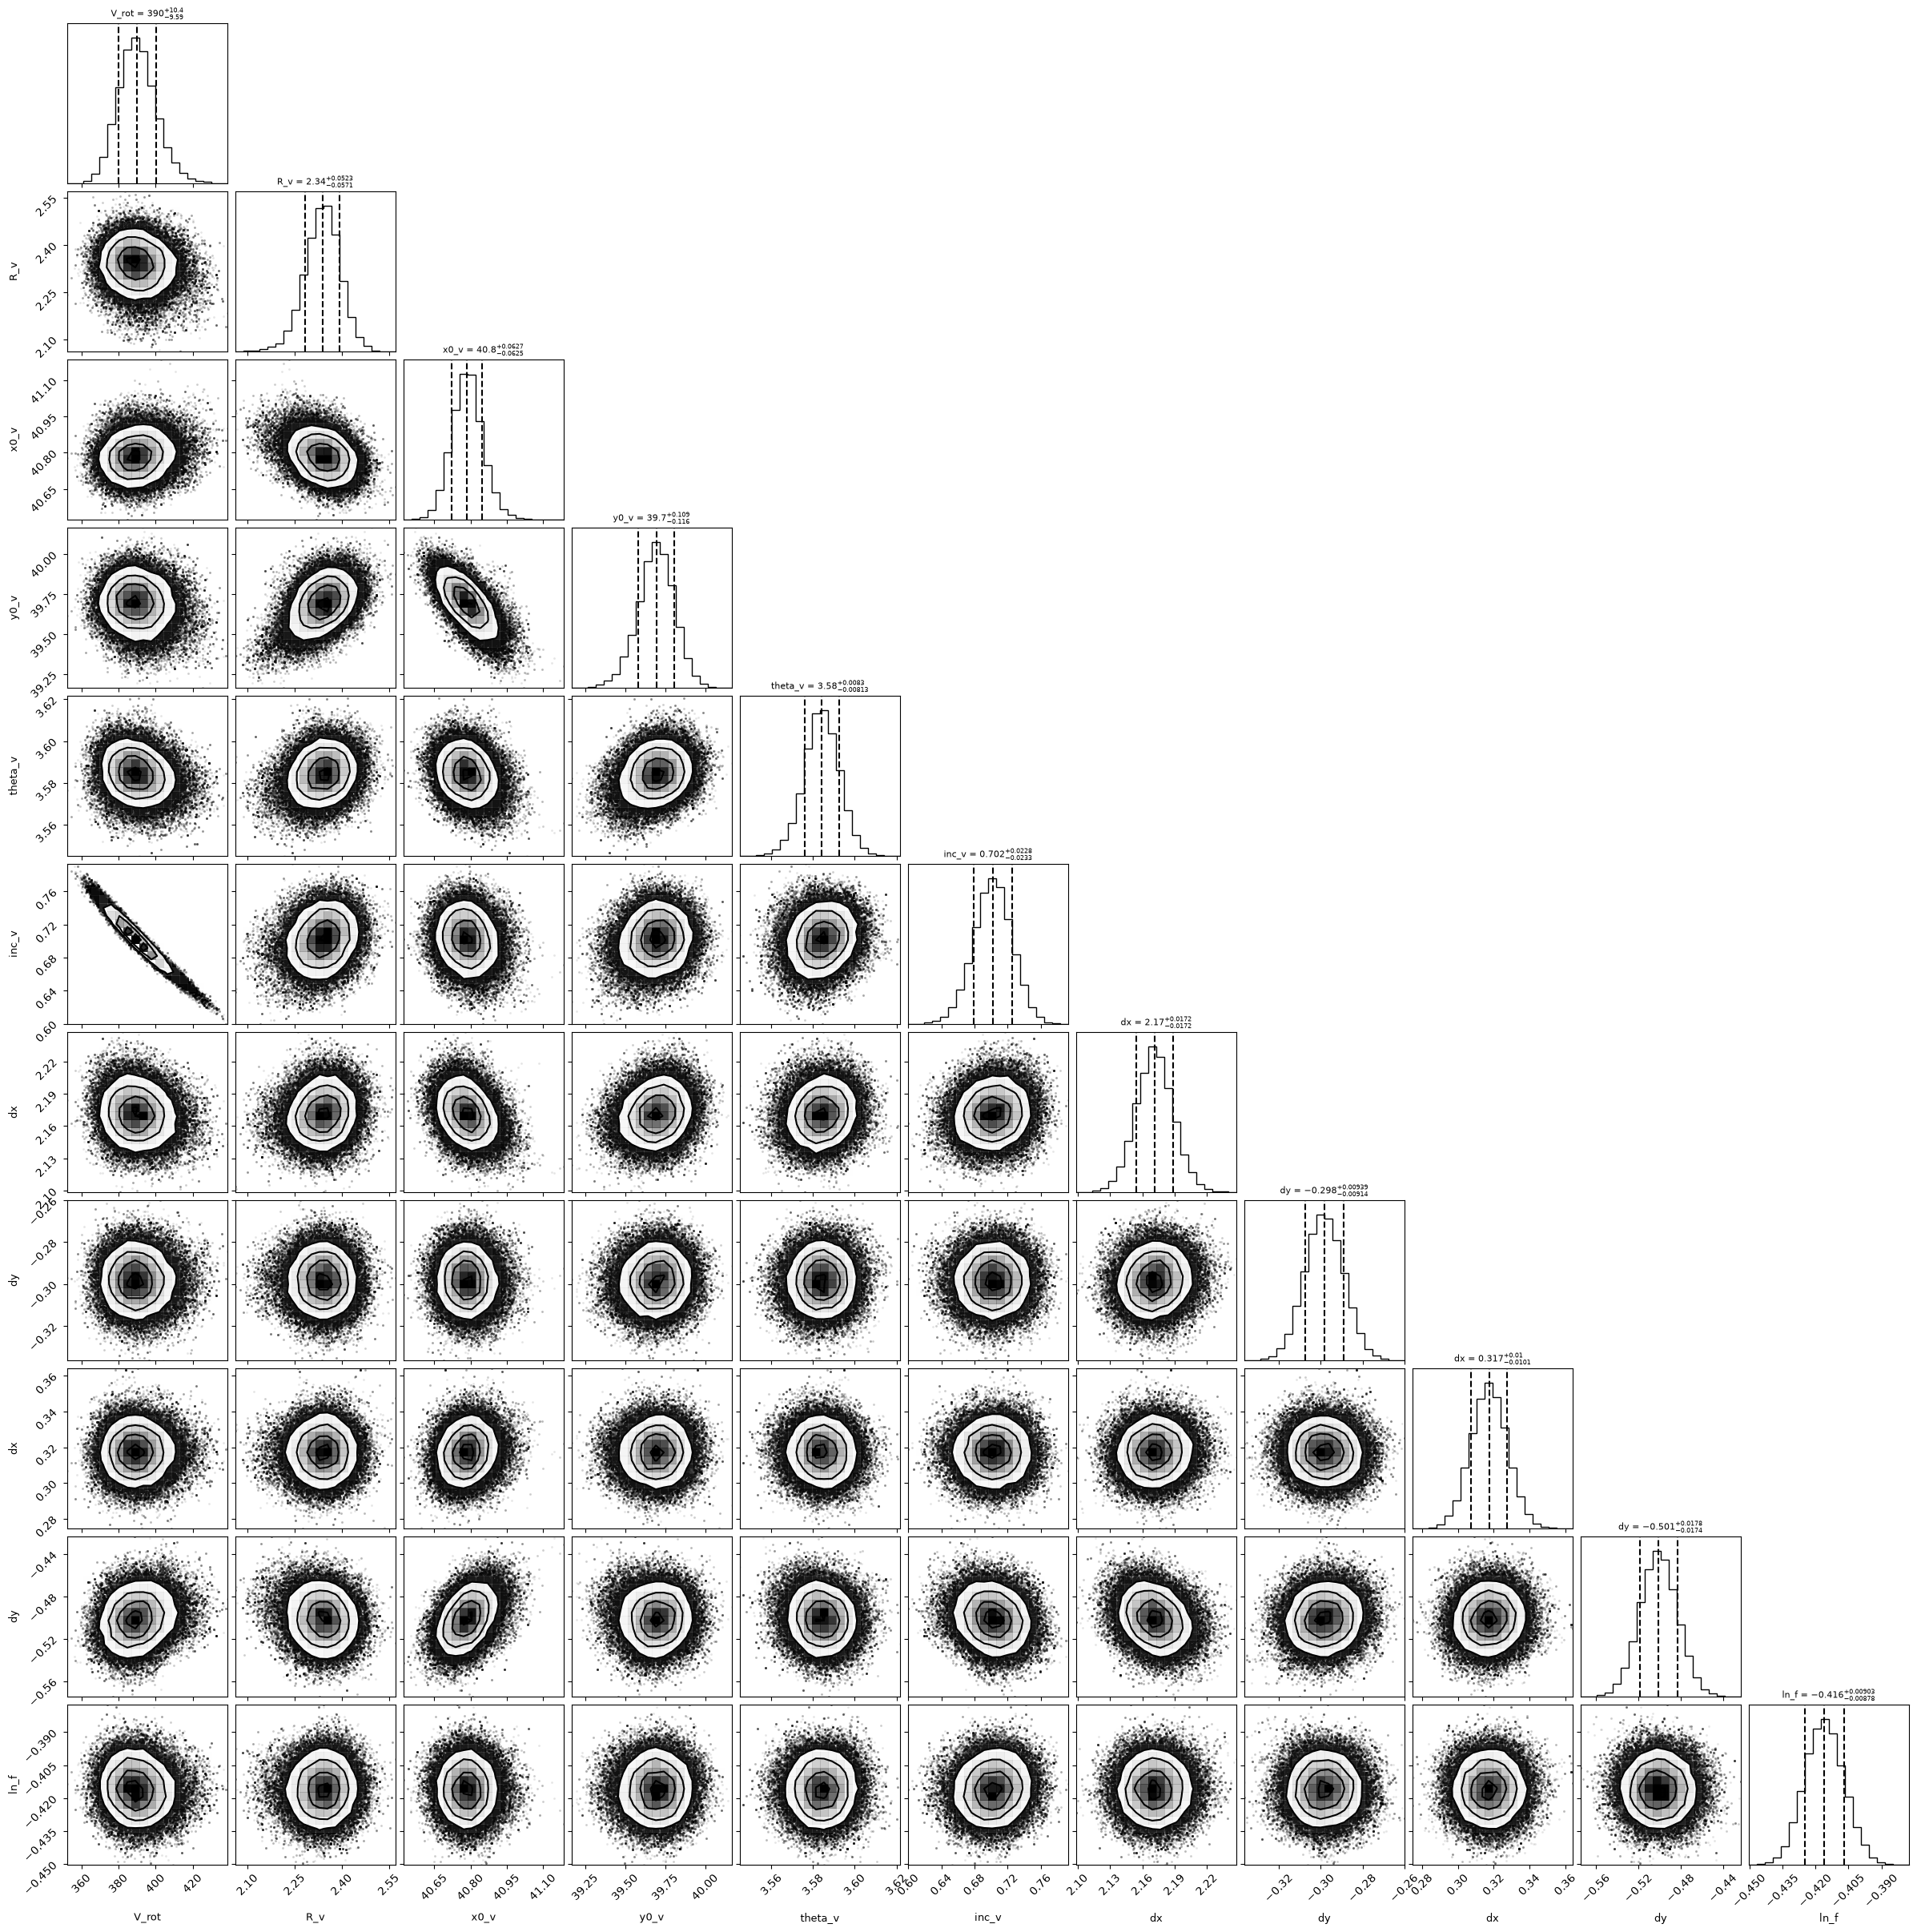

In [17]:
plot.plot_mcmc_corner(flat, names)

### The V_rot - inc_v degeneracy

These two are almost perfectly anti-correlated: the data constrain the product
`V_rot * sin(inc_v)`, not either one separately. Quote `V*sin(i)`.

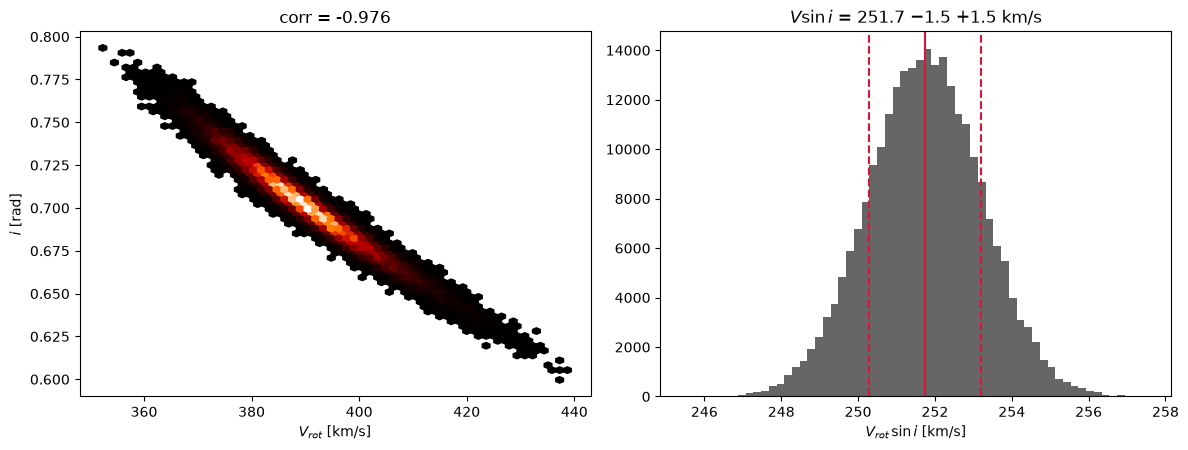

In [18]:
iV, iI = names.index('velocity.V_rot'), names.index('velocity.inc_v')
V, inc = flat[:, iV], flat[:, iI]
Vsini = V*np.sin(inc)

fig, axs = plt.subplots(1, 2, figsize=(12, 4.6))
axs[0].hexbin(V, inc, gridsize=60, cmap='gist_heat', mincnt=1)
axs[0].set_xlabel('$V_{rot}$ [km/s]'); axs[0].set_ylabel('$i$ [rad]')
axs[0].set_title(f'corr = {np.corrcoef(V, inc)[0,1]:+.3f}')

lo, med, hi = np.percentile(Vsini, [16, 50, 84])
axs[1].hist(Vsini, bins=60, color='0.4')
for v, ls in [(lo, '--'), (med, '-'), (hi, '--')]:
    axs[1].axvline(v, color='crimson', ls=ls)
axs[1].set_xlabel('$V_{rot}\\,\\sin i$ [km/s]')
axs[1].set_title(f'$V\\sin i$ = {med:.1f} $-${med-lo:.1f} $+${hi-med:.1f} km/s')
plt.tight_layout(); plt.show()

## Line-of-sight velocity field

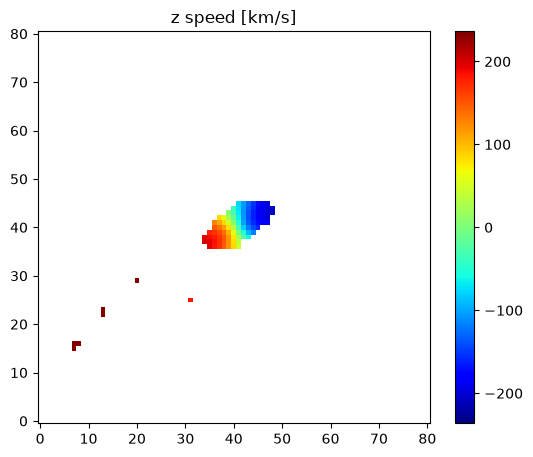

In [19]:
emline = np.average([image_R, image_C], axis=0)
_, _, std = sigma_clipped_stats(emline)
mask = emline > std*5
ny, nx = emline.shape
y, x = torch.meshgrid(torch.arange(ny), torch.arange(nx), indexing='ij')

def field(params, fn=kinematics.arctangent_disk_velocity_model):
    t = lambda k: torch.tensor(float(params[k]))
    return fn(x, y, t('V_rot'), t('R_v'), t('x0_v'), t('y0_v'),
              t('theta_v'), t('inc_v')).detach().cpu().numpy()

vz_np = field(velocity_params)
vz_np[~mask] = np.nan
vmax = np.nanmax(np.abs(vz_np))

plt.figure(figsize=(5.6, 4.6))
plt.imshow(vz_np, cmap='jet', vmin=-vmax, vmax=vmax, origin='lower')
plt.grid(False); plt.colorbar(); plt.title('z speed [km/s]')
plt.tight_layout(); plt.show()

## Intrinsic circular rotation speed

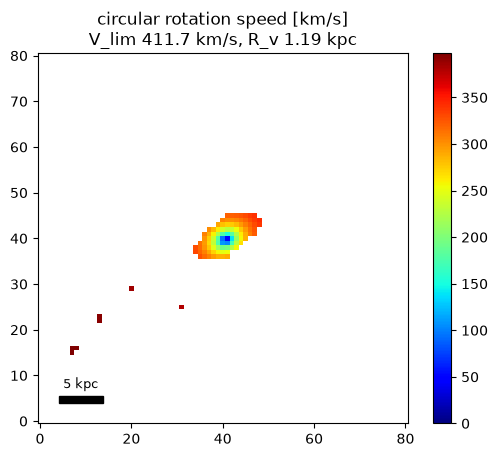

In [20]:
def arctangent_disk_rotation_speed(x, y, V_rot=200., R_v=2., x0_v=0., y0_v=0.,
                                   theta_v=0., inc_v=0., **kwargs):
    '''Intrinsic circular velocity field (not LOS-projected).'''
    dx, dy = x - x0_v, y - y0_v
    cos_t, sin_t = torch.cos(theta_v), torch.sin(theta_v)
    x_p = cos_t*dx + sin_t*dy
    y_p = -sin_t*dx + cos_t*dy
    r = torch.sqrt(x_p**2 + (y_p/torch.cos(inc_v))**2 + 1e-8)
    return (2/torch.pi)*V_rot*torch.atan(r/R_v)

vcirc = field(velocity_params, fn=arctangent_disk_rotation_speed)
vcirc[~mask] = np.nan

fig, ax = plt.subplots(figsize=(5.6, 4.6))
m = ax.imshow(vcirc, cmap='jet', vmin=0, vmax=np.nanmax(vcirc), origin='lower')

bar_kpc = 5
bar_pix = bar_kpc/KPC_PER_PIX
x0, y0 = nx*0.05, ny*0.05
ax.add_patch(patches.Rectangle((x0, y0), bar_pix, 1.5, color='black'))
ax.text(x0 + bar_pix/2, y0 + 2.5, f'{bar_kpc} kpc', color='black',
        ha='center', va='bottom', fontsize=9)

ax.grid(False); fig.colorbar(m, ax=ax)
ax.set_title(f'circular rotation speed [km/s]\n'
             f"V_lim {velocity_params['V_rot']:.1f} km/s, "
             f"R_v {velocity_params['R_v']*KPC_PER_PIX:.2f} kpc")
plt.tight_layout(); plt.show()

## Enclosed dynamical mass

The MAP curve is the black line; the shaded band is the 16-84 percentile of the
posterior, i.e. the error bar the MCMC actually buys us.

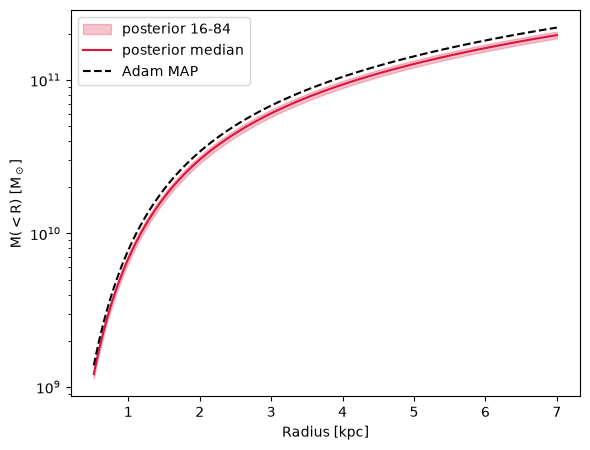

log10 M_dyn(<3 kpc) = 10.782 -0.023 +0.024
log10 M_dyn(<5 kpc) = 11.105 -0.022 +0.024


In [21]:
def arctangent_dynamical_mass(r_kpc, V_rot=200., R_v=2., **kwargs):
    '''M(<R) for the arctangent rotation curve, in M_sun.'''
    G = 4.302e-6                                   # kpc (km/s)^2 / M_sun
    V = (2/np.pi)*V_rot*np.arctan(r_kpc/R_v)
    return V**2*r_kpc/G

r_array = np.linspace(KPC_PER_PIX, 7, 100)

nsub = 2000
sub = np.random.default_rng(0).choice(flat.shape[0], nsub, replace=False)
iR = names.index('velocity.R_v')
curves = np.array([arctangent_dynamical_mass(r_array, flat[k, iV],
                                             flat[k, iR]*KPC_PER_PIX) for k in sub])
lo, med, hi = np.percentile(curves, [16, 50, 84], axis=0)

map_curve = arctangent_dynamical_mass(r_array, velocity_params['V_rot'],
                                      velocity_params['R_v']*KPC_PER_PIX)

plt.figure(figsize=(6, 4.6))
plt.fill_between(r_array, lo, hi, color='crimson', alpha=0.25, label='posterior 16-84')
plt.plot(r_array, med, color='crimson', label='posterior median')
plt.plot(r_array, map_curve, color='black', ls='--', label='Adam MAP')
plt.xlabel('Radius [kpc]'); plt.ylabel(r'M($<$R) [M$_\odot$]')
plt.yscale('log'); plt.legend(frameon=True); plt.grid(False)
plt.tight_layout(); plt.show()

for r in [3.0, 5.0]:
    m = arctangent_dynamical_mass(r, flat[:, iV], flat[:, iR]*KPC_PER_PIX)
    a, b, c = np.percentile(np.log10(m), [16, 50, 84])
    print(f'log10 M_dyn(<{r:.0f} kpc) = {b:.3f} -{b-a:.3f} +{c-b:.3f}')

## Emission-line contours over the direct image

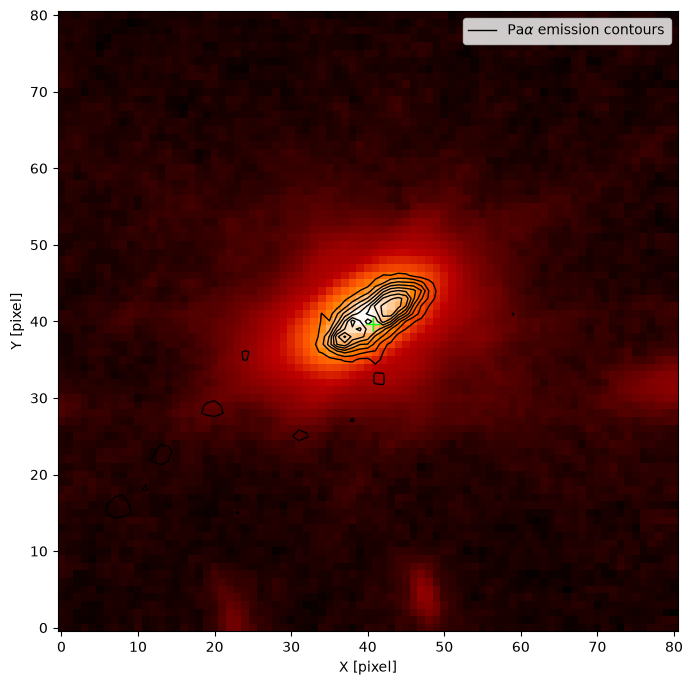

In [22]:
center_emission = (velocity_params['x0_v'], velocity_params['y0_v'])
center_direct   = (coadd_image.shape[1]//2, coadd_image.shape[0]//2)

direct_shifted = scipy.ndimage.shift(
    coadd_image,
    shift=(-(center_emission[1] - center_direct[1]),
           -(center_emission[0] - center_direct[0])),
    order=1, mode='nearest')

em_max = np.nanmax(emline)
levels = np.linspace(0.1*em_max, em_max, 9)

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(direct_shifted, cmap='gist_heat', origin='lower')
ax.contour(emline, levels=levels, colors='black', linewidths=1)
ax.plot(*center_emission, marker='+', color='lime', markersize=10, markeredgewidth=1)
ax.grid(False); ax.set_aspect('equal')
ax.set_xlabel('X [pixel]'); ax.set_ylabel('Y [pixel]')
ax.legend(handles=[Line2D([0], [0], color='black', lw=1,
                          label=r'Pa$\alpha$ emission contours')], frameon=True)
plt.tight_layout(); plt.show()

## Comparison: published Adam fit vs this MCMC

`NOTEBOOK_1_PARAMS` are the numbers printed by cell 17 of `1-fit-kinematics.ipynb`, read
off its stored output. The Adam refit here should reproduce them; the MCMC then says how
wide the posterior around them actually is.

In [23]:
# printed by cell 17 of 1-fit-kinematics.ipynb
NOTEBOOK_1_PARAMS = {
    'velocity.V_rot':   506.8591,
    'velocity.R_v':       3.3512,
    'velocity.x0_v':     42.5087,
    'velocity.y0_v':     41.5563,
    'velocity.theta_v':   2.3243,
    'velocity.inc_v':     0.5040,
    'image.R.dx':         0.6289,
    'image.R.dy':         0.4064,
    'image.C.dx':        -0.2692,
    'image.C.dy':        -0.3980,
}

def _f(v):
    '''get_params() hands back 0-d numpy arrays, which are not numbers.Number.'''
    try:
        return float(v)
    except (TypeError, ValueError):
        return None

adam = {f'velocity.{k}': _f(v) for k, v in velocity_params.items()}
adam = {k: v for k, v in adam.items() if v is not None}
adam.update({'image.R.dx': _f(dispersion_params_R['dx']),
             'image.R.dy': _f(dispersion_params_R['dy']),
             'image.C.dx': _f(dispersion_params_C['dx']),
             'image.C.dy': _f(dispersion_params_C['dy'])})

hdr = (f'{"parameter":<18}{"notebook 1":>12}{"Adam here":>12}{"diff":>9}'
       f'{"MCMC median":>13}{"-1sig":>8}{"+1sig":>8}{"(MCMC-nb1)/sig":>16}')
print(hdr); print('-'*len(hdr))
for name, v1 in NOTEBOOK_1_PARAMS.items():
    j = names.index(name)
    lo, med, hi = np.percentile(flat[:, j], [16, 50, 84])
    sig = 0.5*(hi - lo)
    va = adam.get(name, np.nan)
    print(f'{name:<18}{v1:>12.4f}{va:>12.4f}{va-v1:>9.4f}'
          f'{med:>13.4f}{med-lo:>8.4f}{hi-med:>8.4f}{(med-v1)/sig:>16.1f}')

print(f'\nmax |Adam here - notebook 1| = '
      f'{max(abs(adam[k]-v) for k, v in NOTEBOOK_1_PARAMS.items()):.4f}')

parameter           notebook 1   Adam here     diff  MCMC median   -1sig   +1sig  (MCMC-nb1)/sig
------------------------------------------------------------------------------------------------
velocity.V_rot        506.8591    411.6582 -95.2009     389.7435  9.5911 10.3964           -11.7
velocity.R_v            3.3512      2.3052  -1.0460       2.3398  0.0571  0.0523           -18.5
velocity.x0_v          42.5087     40.6918  -1.8169      40.7853  0.0625  0.0627           -27.5
velocity.y0_v          41.5563     39.6983  -1.8580      39.6955  0.1155  0.1085           -16.6
velocity.theta_v        2.3243      3.5758   1.2515       3.5841  0.0081  0.0083           153.3
velocity.inc_v          0.5040      0.6521   0.1481       0.7024  0.0233  0.0228             8.6
image.R.dx              0.6289      2.1768   1.5479       2.1714  0.0172  0.0172            89.5
image.R.dy              0.4064     -0.3029  -0.7093      -0.2984  0.0091  0.0094           -76.1
image.C.dx             -0.2692

quantity               from nb1 par  MCMC median    -1sig    +1sig
V sin(i) [km/s]            244.7785     251.7484   1.4683   1.4535
R_v [kpc]                    1.7322       1.2094   0.0295   0.0270
log10 M_dyn(<5kpc)          11.2678      11.1045   0.0221   0.0237


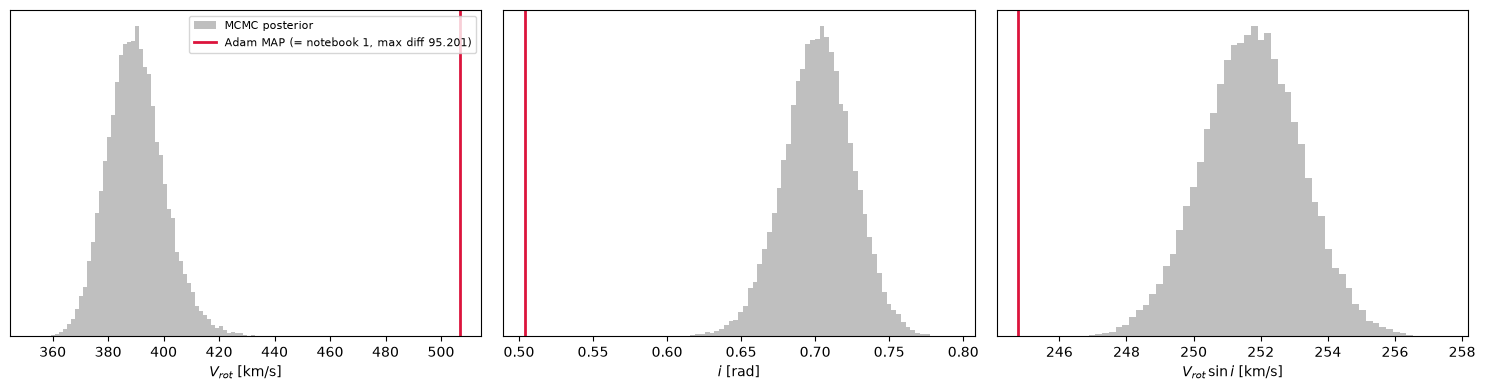

In [24]:
# Derived quantities. NOTE: 1-fit-kinematics.ipynb reports none of these except
# M_dyn -- V*sin(i) is computed here from its V_rot and inc_v, not read from it.
def derived(V_rot, R_v_pix, inc):
    return (V_rot*np.sin(inc), R_v_pix*KPC_PER_PIX,
            np.log10(arctangent_dynamical_mass(5.0, V_rot, R_v_pix*KPC_PER_PIX)))

d1 = derived(NOTEBOOK_1_PARAMS['velocity.V_rot'], NOTEBOOK_1_PARAMS['velocity.R_v'],
             NOTEBOOK_1_PARAMS['velocity.inc_v'])
dm = derived(flat[:, iV], flat[:, iR], flat[:, iI])

print(f'{"quantity":<22}{"from nb1 par":>13}{"MCMC median":>13}{"-1sig":>9}{"+1sig":>9}')
for label, v1, s in [('V sin(i) [km/s]', d1[0], dm[0]),
                     ('R_v [kpc]',       d1[1], dm[1]),
                     ('log10 M_dyn(<5kpc)', d1[2], dm[2])]:
    lo, med, hi = np.percentile(s, [16, 50, 84])
    print(f'{label:<22}{v1:>13.4f}{med:>13.4f}{med-lo:>9.4f}{hi-med:>9.4f}')

# posterior vs the two point estimates
# One Adam line only: the refit here IS notebook 1's fit -- same config, same
# optimiser, agreeing to <0.1% (see the table above). Two lines would overplot.
dmax = max(abs(adam[k] - v) for k, v in NOTEBOOK_1_PARAMS.items())
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, s_, v1, label in [
        (axs[0], flat[:, iV], NOTEBOOK_1_PARAMS['velocity.V_rot'], '$V_{rot}$ [km/s]'),
        (axs[1], flat[:, iI], NOTEBOOK_1_PARAMS['velocity.inc_v'], '$i$ [rad]'),
        (axs[2], dm[0],       d1[0],                               r'$V_{rot}\,\sin i$ [km/s]')]:
    ax.hist(s_, bins=60, color='0.75', label='MCMC posterior')
    ax.axvline(v1, color='crimson', lw=2,
               label=f'Adam MAP (= notebook 1, max diff {dmax:.3f})')
    ax.set_xlabel(label); ax.set_yticks([]); ax.grid(False)
axs[0].legend(frameon=True, fontsize=8)
plt.tight_layout(); plt.show()

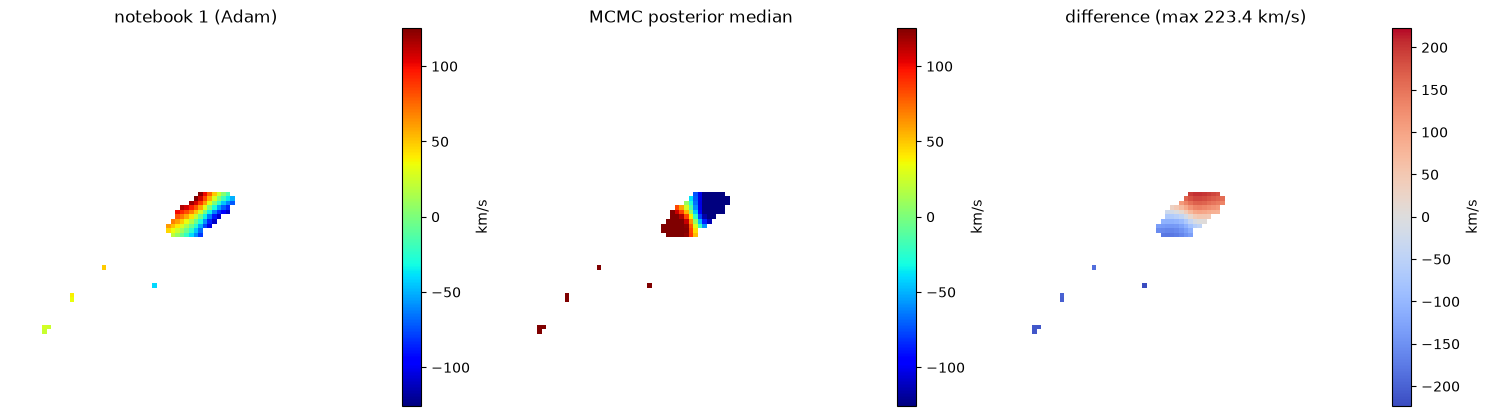

In [25]:
# velocity fields side by side, and their difference
def vfield(p):
    v = kinematics.arctangent_disk_velocity_model(
        x, y, *[torch.tensor(float(p[f'velocity.{k}']))
                for k in ('V_rot', 'R_v', 'x0_v', 'y0_v', 'theta_v', 'inc_v')]
    ).detach().cpu().numpy()
    out = v.copy(); out[~mask] = np.nan
    return out

mcmc_params = {n: np.median(flat[:, names.index(n)]) for n in names[:-1]}
v1_field, vm_field = vfield(NOTEBOOK_1_PARAMS), vfield(mcmc_params)
vmax = np.nanmax(np.abs(v1_field))
dmax = np.nanmax(np.abs(v1_field - vm_field))

fig, axs = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, im, t, kw in [
        (axs[0], v1_field, 'notebook 1 (Adam)',   dict(cmap='jet', vmin=-vmax, vmax=vmax)),
        (axs[1], vm_field, 'MCMC posterior median', dict(cmap='jet', vmin=-vmax, vmax=vmax)),
        (axs[2], v1_field - vm_field, f'difference (max {dmax:.1f} km/s)',
         dict(cmap='coolwarm', vmin=-dmax, vmax=dmax))]:
    m = ax.imshow(im, origin='lower', **kw)
    ax.set_title(t); ax.grid(False); ax.set_axis_off()
    fig.colorbar(m, ax=ax, fraction=0.046, label='km/s')
plt.tight_layout(); plt.show()

## What the posterior median actually fits

Push the posterior-median parameters back through the forward model to get the rectified
images, the velocity fields, and the R-C residual the likelihood is built on. Same four
panels as the Adam fit above, so the two are directly comparable.

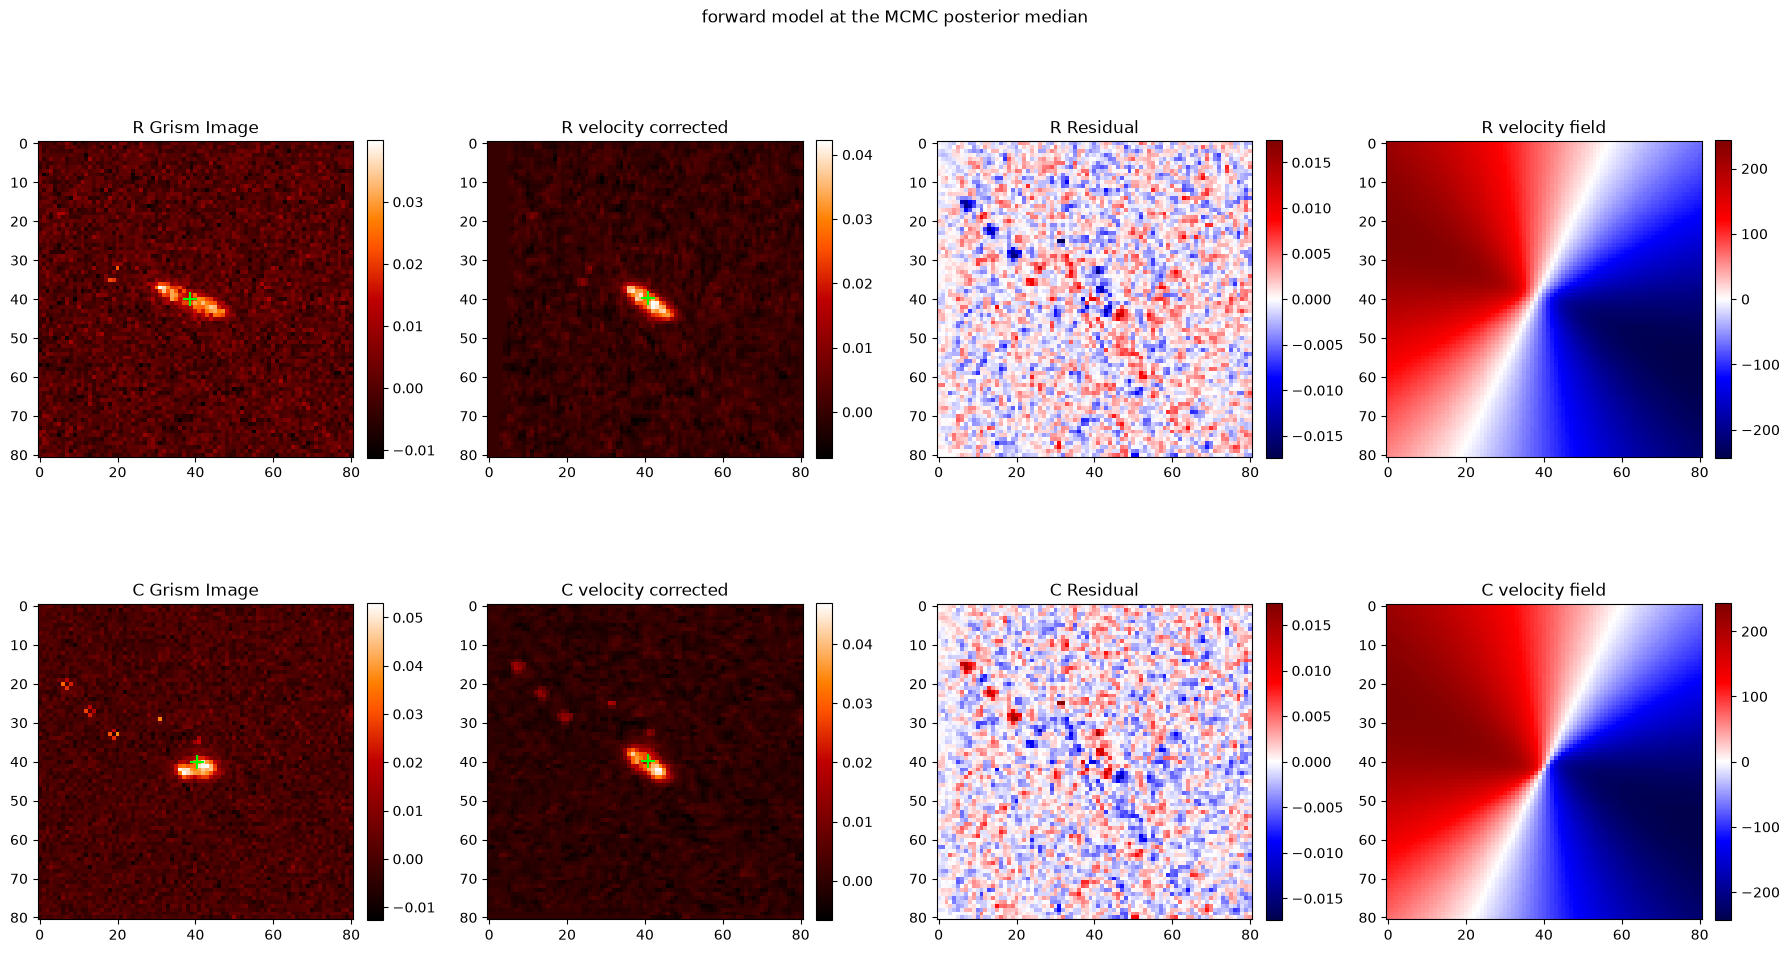

In [26]:
# write the posterior medians into the fitter and re-run the forward model
kinematics_fitter.set_params_dict(mcmc_params)
kinematics_fitter._reset_state()
with torch.no_grad():
    kinematics_fitter.loss()

image_R_mc, image_C_mc, vz_R_mc, vz_C_mc = kinematics_fitter.get_fitting_results()
vel_mc, disp_R_mc, disp_C_mc = kinematics_fitter.get_params()

fig, axs = plt.subplots(2, 4, figsize=(18, 10))
plot.plot_kinematics_fitting_result(true_grism_R, image_R_mc, vz_R_mc, image_C_mc, 'R',
                                    axs[0], vel_mc, disp_R_mc)
plot.plot_kinematics_fitting_result(true_grism_C, image_C_mc, vz_C_mc, image_R_mc, 'C',
                                    axs[1], vel_mc, disp_C_mc)
fig.suptitle('forward model at the MCMC posterior median', y=1.005)
plt.tight_layout(); plt.show()

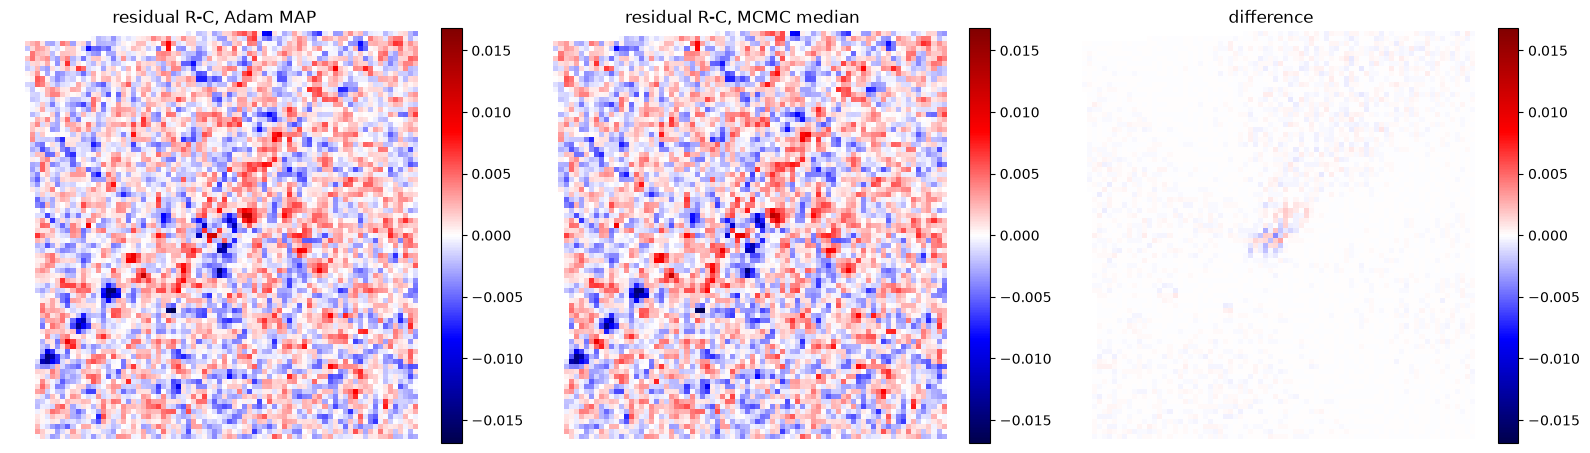

                SSE (masked)    chi2/N   resid rms
Adam MAP             0.05126    0.4364    0.002886
MCMC median          0.05102    0.4343    0.002879

mask keeps 6142 of 6561 pixels; sigma_R-C = 0.004373


In [27]:
# the R-C residual: what the likelihood actually sums over
def _np(a):
    '''get_fitting_results() returns ndarrays; loss() caches tensors. Take either.'''
    return a.detach().cpu().numpy() if hasattr(a, 'detach') else np.asarray(a)

resid_adam = _np(image_R)    - _np(image_C)
resid_mcmc = _np(image_R_mc) - _np(image_C_mc)

nmask = getattr(kinematics_fitter, 'mcmc_mask', None)
if nmask is None:
    kinematics_fitter.setup_noise_model()
    nmask = kinematics_fitter.mcmc_mask
nmask = _np(nmask).astype(bool)
sigma = float(np.sqrt(kinematics_fitter.mcmc_var_base))

rmax = np.nanmax(np.abs(np.where(nmask, resid_adam, np.nan)))
fig, axs = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, im, t in [(axs[0], np.where(nmask, resid_adam, np.nan), 'residual R-C, Adam MAP'),
                  (axs[1], np.where(nmask, resid_mcmc, np.nan), 'residual R-C, MCMC median'),
                  (axs[2], np.where(nmask, resid_adam - resid_mcmc, np.nan), 'difference')]:
    m = ax.imshow(im, origin='lower', cmap='seismic', vmin=-rmax, vmax=rmax)
    ax.set_title(t); ax.grid(False); ax.set_axis_off()
    fig.colorbar(m, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

print(f'{"":<14}{"SSE (masked)":>14}{"chi2/N":>10}{"resid rms":>12}')
for label, r in [('Adam MAP', resid_adam), ('MCMC median', resid_mcmc)]:
    sse = float(np.sum(r[nmask]**2))
    print(f'{label:<14}{sse:>14.5f}{sse/(nmask.sum()*sigma**2):>10.4f}'
          f'{np.std(r[nmask]):>12.6f}')
print(f'\nmask keeps {nmask.sum()} of {nmask.size} pixels; '
      f'sigma_R-C = {sigma:.6f}')

# restore the Adam MAP so later cells are unaffected
kinematics_fitter.set_params_dict({k: adam[k] for k in mcmc_params if k in adam})
kinematics_fitter._reset_state()
with torch.no_grad():
    kinematics_fitter.loss()

## Validation: noiseless-mock recovery

Build a mock from a known parameter vector with the noise switched off, then re-fit it.
With no noise there is no statistics left, so a self-consistent generator and fitter must
return the injected values essentially exactly. Whatever comes back non-zero is systematic
-- and it bounds how much of any measured "bias" is the estimator versus the test harness.

**Known issue:** this currently returns V_rot high by ~4% and recovers half-pixel offsets
from a zero-offset injection, which points at the gather/scatter convention in
`make_mock_data`, not at the fitter. Until that is fixed the ensemble bias numbers in
`../MCMC_STATUS.md` are upper bounds.

In [28]:
if RUN_FLOOR_TEST:
    truth = {n: float(adam[n]) for n in mcmc_params if n in adam}
    kinematics_fitter.set_params_dict(truth)
    kinematics_fitter.make_mock_data(sigma_R=0.0, sigma_C=0.0, inplace=True)

    sse_at_truth = float(np.sum(
        ((_np(kinematics_fitter.image_R) - _np(kinematics_fitter.image_C))[nmask])**2))
    denom = kinematics_fitter.n_mcmc_pix*kinematics_fitter.mcmc_var_base
    print(f'SSE at the injected truth = {sse_at_truth:.6g}'
          f'   ratio to N*var_base = {sse_at_truth/denom:.4f}'
          f'   {"OK" if sse_at_truth/denom < 0.1 else "HIGH"}')

    # start displaced and re-fit: where does the estimator land?
    kinematics_fitter.set_params_dict({k: v*1.02 for k, v in truth.items()})
    kinematics_fitter.current_stage = 0
    kinematics_fitter._assign_cfgs_for_stage(0)
    kinematics_fitter.fit_gradient()
    vel, dR, dC = kinematics_fitter.get_params()
    got = {f'velocity.{k}': _f(v) for k, v in vel.items()}
    got.update({'image.R.dx': _f(dR['dx']), 'image.R.dy': _f(dR['dy']),
                'image.C.dx': _f(dC['dx']), 'image.C.dy': _f(dC['dy'])})

    print(f'\n{"parameter":<18}{"injected":>11}{"recovered":>11}{"bias":>10}{"%":>9}')
    for n in truth:
        b = got[n] - truth[n]
        pct = 100*b/truth[n] if truth[n] else np.nan
        print(f'{n:<18}{truth[n]:>11.4f}{got[n]:>11.4f}{b:>+10.4f}{pct:>+9.2f}')

    kinematics_fitter.restore_true_data()
    kinematics_fitter.set_params_dict(truth)
    kinematics_fitter._reset_state()
    with torch.no_grad():
        kinematics_fitter.loss()
    print('\ntrue data restored')
else:
    print('RUN_FLOOR_TEST = False -- skipping')

RUN_FLOOR_TEST = False -- skipping


## Batch: run every source from here

`run_source()` is the whole per-source pipeline as one call -- generate the config,
Adam fit, freeze the noise model, sample, save to `results/ID<n>/`, return the derived
quantities. Set `BATCH_IDS` at the top of the notebook and run the cell below; nothing
needs to happen at a terminal.

`nsteps=None` uses the config value (8000, ~2.5 h per source). Drop it to a few hundred
for a smoke test first -- the fit is what usually fails, not the sampler.

In [29]:
def run_source(sid, nsteps=None, nburn=None, inc_prior=None, save=True, plots=False):
    '''Full pipeline for one source. Returns a dict of derived quantities.'''
    outdir = os.path.join(RESULTS, f'ID{sid}')
    os.makedirs(outdir, exist_ok=True)
    cfg = f'ID{sid}/config_kinematics.yaml'
    if not os.path.exists(os.path.join(DATA, cfg)):
        make_config(sid)

    src_i = lookup_source(sid)
    f = fitting.KinematicsFitter(config_path=cfg)
    f.fit_all()

    if inc_prior is not None:                     # (mu, sigma) in radians
        mu, sg = inc_prior
        f.config.setdefault('mcmc', {}).setdefault('priors', {})['velocity.inc_v'] = {
            'type': 'gaussian', 'mu': float(mu), 'sigma': float(sg),
            'min': 0.0873, 'max': 1.4835}

    f.setup_noise_model()
    f.fit_MCMC(nsteps=nsteps, nburn=nburn)
    chain_path = os.path.join(outdir, f'ID{sid}_chain.npz')
    if save:
        f.save_mcmc(chain_path)

    names = f.mcmc_param_names
    flat = f.mcmc_chain
    gi = {n: names.index(n) for n in names}
    V = flat[:, gi['velocity.V_rot']]
    inc = flat[:, gi['velocity.inc_v']]
    Rv = flat[:, gi['velocity.R_v']]
    kpp = kpc_per_pixel(src_i['zspec'])
    vsini = V*np.sin(inc)
    mdyn = np.log10(arctangent_dynamical_mass(5.0, V, Rv*kpp))

    q = lambda a: np.percentile(a, [16, 50, 84])
    row = {'id': sid, 'z': src_i['zspec'], 'kpc_per_pix': kpp,
           'loss': float(f.loss()), 'acc': float(np.mean(f.mcmc_sampler.acceptance_fraction)),
           'railed_inc': bool(np.median(inc) < 0.10 or np.median(inc) > 1.45)}
    for label, arr in [('V_rot', V), ('inc_v', inc), ('Vsini', vsini),
                       ('R_v_kpc', Rv*kpp), ('logM5', mdyn)]:
        lo, me, hi = q(arr)
        row[label], row[label+'_lo'], row[label+'_hi'] = me, me-lo, hi-me
    if save:
        # `row` already holds scalar Vsini/logM5/R_v_kpc summaries, so prefix the
        # full sample arrays rather than colliding with those keyword names.
        np.savez_compressed(
            os.path.join(outdir, f'ID{sid}_derived.npz'),
            samples_Vsini=vsini, samples_logM5=mdyn, samples_R_v_kpc=Rv*kpp,
            **{k: v for k, v in row.items() if not isinstance(v, bool)})
    if plots:
        plot.plot_mcmc_corner(flat, names)
    return row

In [30]:
if BATCH_IDS:
    rows = []
    for sid in BATCH_IDS:
        print(f'\n{"="*64}\nID {sid}\n{"="*64}')
        try:
            rows.append(run_source(sid))
        except Exception as exc:
            print(f'ID {sid} FAILED: {type(exc).__name__}: {exc}')

    hdr = (f'{"ID":>7}{"z":>8}{"V_rot":>9}{"inc deg":>9}{"Vsini":>9}'
           f'{"+-":>7}{"logM5":>8}{"acc":>7}  flag')
    print('\n' + hdr); print('-'*len(hdr))
    for r in rows:
        flag = 'INC RAILED' if r['railed_inc'] else ''
        print(f'{r["id"]:>7}{r["z"]:>8.4f}{r["V_rot"]:>9.1f}'
              f'{np.rad2deg(r["inc_v"]):>9.1f}{r["Vsini"]:>9.1f}'
              f'{0.5*(r["Vsini_lo"]+r["Vsini_hi"]):>7.1f}{r["logM5"]:>8.3f}'
              f'{r["acc"]:>7.3f}  {flag}')
else:
    print('BATCH_IDS is empty -- set it at the top of the notebook to run more sources.')

BATCH_IDS is empty -- set it at the top of the notebook to run more sources.


## Headline result

`V*sin(i)` is what the grism data measure directly. To get `V_rot` you divide by
`sin(i)`, and the inclination comes from the imaging -- so the error budget has two
parts, and the second one dominates:

- **statistical**, from the MCMC posterior on `V*sin(i)` (a few km/s)
- **inclination systematic**, from `dV/V = cot(i) * di`, using the scatter BETWEEN
  independent morphology methods rather than any single fit's formal error

`INC_METHOD_SCATTER` below is the honest width: a single pysersic fit reports ~0.01 rad,
which is far too tight for a galaxy a single Sersic cannot describe.

In [31]:
INC_METHOD_SCATTER = 0.044      # rad (~2.5 deg), scatter between morphology methods

i_phot = PYSERSIC_INC if PYSERSIC_INC is not None else np.median(flat[:, iI])
di = max(PYSERSIC_INC_SIG or 0.0, INC_METHOD_SCATTER)

vs_lo, vs_med, vs_hi = np.percentile(Vsini, [16, 50, 84])
vs_err = 0.5*(vs_hi - vs_lo)

V_phot = vs_med/np.sin(i_phot)
V_stat = vs_err/np.sin(i_phot)                     # from V*sin(i)
V_sys = V_phot/np.tan(i_phot)*di                   # from the inclination

R_v_kpc = np.median(flat[:, iR])*KPC_PER_PIX
logM = np.log10(arctangent_dynamical_mass(5.0, V_phot, R_v_kpc))
dlogM_stat = 2*V_stat/V_phot/np.log(10)
dlogM_sys = 2*V_sys/V_phot/np.log(10)

print(f'ID {ID}   z = {z:.4f}   {KPC_PER_PIX:.4f} kpc/pixel\n')
print(f'  V*sin(i)              = {vs_med:8.2f} +- {vs_err:.2f} km/s     (measured)')
print(f'  inclination           = {np.rad2deg(i_phot):8.2f} +- {np.rad2deg(di):.2f} deg'
      f'      (imaging)')
print(f'  V_rot                 = {V_phot:8.1f} +- {V_stat:.1f} (stat) '
      f'+- {V_sys:.1f} (incl) km/s')
print(f'  R_v                   = {R_v_kpc:8.3f} kpc')
print(f'  log10 M_dyn(<5 kpc)   = {logM:8.3f} +- {dlogM_stat:.3f} (stat) '
      f'+- {dlogM_sys:.3f} (incl) dex')
print(f'\n  inclination dominates: {V_sys/V_stat:.0f}x the statistical error on V_rot')

# for reference: what the kinematics alone prefer, no imaging input
i_kin = np.median(flat[:, iI])
print(f'\n  kinematic-only inclination = {np.rad2deg(i_kin):.2f} deg '
      f'-> V_rot = {vs_med/np.sin(i_kin):.1f} km/s')

np.savez_compressed(out('headline.npz'),
                    Vsini=vs_med, Vsini_err=vs_err, inc_phot=i_phot, inc_err=di,
                    V_rot=V_phot, V_rot_stat=V_stat, V_rot_sys=V_sys,
                    R_v_kpc=R_v_kpc, logM5=logM,
                    logM5_stat=dlogM_stat, logM5_sys=dlogM_sys, z=z)
print('\nsaved ->', out('headline.npz'))

ID 3700   z = 1.1231   0.5169 kpc/pixel

  V*sin(i)              =   251.75 +- 1.46 km/s     (measured)
  inclination           =    64.34 +- 2.52 deg      (imaging)
  V_rot                 =    279.3 +- 1.6 (stat) +- 5.9 (incl) km/s
  R_v                   =    1.209 kpc
  log10 M_dyn(<5 kpc)   =   10.815 +- 0.005 (stat) +- 0.018 (incl) dex

  inclination dominates: 4x the statistical error on V_rot

  kinematic-only inclination = 40.24 deg -> V_rot = 389.7 km/s

saved -> /Users/aakavan/Astro_Research/Galaxy_Kinematics/DINGO_development/results/ID3700/ID3700_headline.npz


## Summary

This notebook runs the whole pipeline from an ID: catalogue lookup -> pysersic morphology
-> inclination prior -> Adam fit -> MCMC posterior -> derived quantities, with the four
switches at the top choosing what is recomputed versus loaded.

Widths below are raw likelihood widths. The ensemble calibration
(`validate_mcmc.py ensemble`) has not been redone since the mask and redshift fixes, and
the mock generator has a known systematic, so **no validated inflation factor is applied
yet**. See `../MCMC_STATUS.md`.

In [32]:
print(f'{"quantity":<28}{"median":>12}{"-1sigma":>10}{"+1sigma":>10}')
rows = [('V_rot [km/s]',      flat[:, iV]),
        ('inc_v [rad]',       flat[:, iI]),
        ('inc_v [deg]',       np.rad2deg(flat[:, iI])),
        ('V sin(i) [km/s]',   Vsini),
        ('R_v [kpc]',         flat[:, iR]*KPC_PER_PIX),
        ('log10 M_dyn(<5kpc)', np.log10(arctangent_dynamical_mass(
            5.0, flat[:, iV], flat[:, iR]*KPC_PER_PIX)))]
for label, s in rows:
    a, b, c = np.percentile(s, [16, 50, 84])
    print(f'{label:<28}{b:>12.4f}{b-a:>10.4f}{c-b:>10.4f}')

quantity                          median   -1sigma   +1sigma
V_rot [km/s]                    389.7435    9.5911   10.3964
inc_v [rad]                       0.7024    0.0233    0.0228
inc_v [deg]                      40.2438    1.3338    1.3039
V sin(i) [km/s]                 251.7484    1.4683    1.4535
R_v [kpc]                         1.2094    0.0295    0.0270
log10 M_dyn(<5kpc)               11.1045    0.0221    0.0237
